# Modeling


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from math import ceil

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
import shap

## Prepare data for model

In [2]:
df = pd.read_csv('data/output/26_03_04.csv')

uneven class distributions -> stratified train-test-split required

In [4]:
# Split into features and targets
X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_average', 'veg_class', 'event_label', 'recovery_dep',
       't2mmax', 't2mmax_prev', 't2mmax_anomaly', 't2mmin', 't2mmin_prev', 't2min_anomaly'], axis=1)

# Rename variable names to match abbreviations from document
X = X.rename(columns={
    'n_days': 'ND',
    't2m': 'T2m',
    'prec': 'P',
    'soil_moist': 'RSM',
    'evap': 'E',
    'evap_pot': 'PE',
    't2m_prev': 'T2m_prev',
    'prec_prev': 'P_prev',
    'soil_moist_prev': 'RSM_prev',
    'evap_prev': 'E_prev',
    'evap_pot_prev': 'PE_prev',
    't2m_anomaly': 'A_T2m',
    'prec_anomaly': 'A_P',
    'soil_moist_anomaly': 'A_RSM',
    'evap_anomaly': 'A_E',
    'evap_pot_anomaly': 'A_PE'
})

y_resl = df['resilience']
y_rest = df['resistance']
y_rec = df['recovery']
y_anom = df['kndvi_anomaly_strength_average']

# Split into train and test set
X_train_resl, X_test_resl, y_train_resl, y_test_resl = train_test_split(X, y_resl, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resilience
X_train_rest, X_test_rest, y_train_rest, y_test_rest = train_test_split(X, y_rest, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resistance
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y_rec, test_size=0.2, random_state=123, stratify=df['veg_class']) # Recovery
X_train_anom, X_test_anom, y_train_anom, y_test_anom = train_test_split(X, y_anom, test_size=0.2, random_state=123, stratify=df['veg_class']) # Anomaly strength


In [ ]:
# Store vegetation class information for later
test_indices_resl = X_test_resl.index
veg_classes_resl = df.loc[test_indices_resl, 'veg_class']

test_indices_rest = X_test_rest.index
veg_classes_rest = df.loc[test_indices_rest, 'veg_class']

test_indices_rec = X_test_rec.index
veg_classes_rec = df.loc[test_indices_rec, 'veg_class']

test_indices_anom = X_test_anom.index
veg_classes_anom = df.loc[test_indices_anom, 'veg_class']

# Create group mappings based on traits and climate
trait_group_mapping = {
    # Group A: Forests
    1: 'Forest', 2: 'Forest', 3: 'Forest', 4: 'Forest', 
    5: 'Forest', 8: 'Forest', 18: 'Forest',
    
    # Group B: Shrublands & Grasslands
    6: 'Shrub/Grass', 7: 'Shrub/Grass', 9: 'Shrub/Grass', 
    10: 'Shrub/Grass', 19: 'Shrub/Grass', 20: 'Shrub/Grass',
    
    # Group C: Human-Impacted
    12: 'Human/Agricultural', 13: 'Urban', 14: 'Mosaic',
    
    # Group D: Wetlands & Water
    11: 'Wetland', 17: 'Water',
    
    # Group E: Non-Vegetated
    15: 'Ice/Snow', 16: 'Barren'
}

climate_group_mapping = {
    # Boreal/Cold Climate
    1: 'Boreal/Cold',      # Evergreen Needleleaf Forest
    3: 'Boreal/Cold',      # Deciduous Needleleaf Forest
    18: 'Boreal/Cold',     # Wooded Tundra
    19: 'Boreal/Cold',     # Mixed Tundra
    20: 'Boreal/Cold',     # Bare Ground Tundra
    15: 'Boreal/Cold',     # Snow and Ice

    # Temperate Climate
    4: 'Temperate',        # Deciduous Broadleaf Forest
    5: 'Temperate',        # Mixed Forest
    10: 'Temperate',       # Grassland
    12: 'Temperate',       # Cropland
    14: 'Temperate',       # Cropland/Natural Vegetation Mosaic
    
    # Tropical/Subtropical
    2: 'Tropical',         # Evergreen Broadleaf Forest
    8: 'Tropical',         # Woody Savannas
    9: 'Tropical',         # Savannas
    
    # Arid/Semi-Arid
    6: 'Arid',             # Closed Shrublands
    7: 'Arid',             # Open Shrublands
    16: 'Arid',            # Barren or Sparsely Vegetated
    
    # Other/Special
    11: 'Wetland',         # Permanent Wetland
    13: 'Urban',           # Urban and Built-Up
    17: 'Ocean'            # Ocean
}

# Create mapping functions
def get_trait_group(veg_class):
    return trait_group_mapping.get(veg_class, 'Unknown')

def get_climate_group(veg_class):
    return climate_group_mapping.get(veg_class, 'Unknown')

# Apply to test data
trait_groups_resl = veg_classes_resl.apply(get_trait_group)
climate_groups_resl = veg_classes_resl.apply(get_climate_group)

trait_groups_rest = veg_classes_rest.apply(get_trait_group)
climate_groups_rest = veg_classes_rest.apply(get_climate_group)

trait_groups_rec = veg_classes_rec.apply(get_trait_group)
climate_groups_rec = veg_classes_rec.apply(get_climate_group)

trait_groups_anom = veg_classes_anom.apply(get_trait_group)
climate_groups_anom = veg_classes_anom.apply(get_climate_group)

## Extreme Gradient Boosting


### A) Resilience
#### Hyperparameter tuning

In [122]:
# Define hyperparameter space 
space = { 
    'eta': hp.loguniform('eta', np.log(0.001), np.log(0.1)), 
    'gamma': hp.uniform('gamma', 0, 10), 
    'max_depth': hp.quniform('max_depth', 2, 5, 1), 
    'min_child_weight': hp.loguniform('min_child_weight', np.log(5), np.log(50)), 
    'subsample': hp.uniform('subsample', 0.4, 0.8), 
    'colsample_bytree': hp.uniform('colsample_bytree', 0.4, 0.8), 
    'alpha': hp.loguniform('alpha', np.log(1), np.log(100)), 
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1), np.log(100)) }

In [123]:
def objective_resl(space):
    # Inner CV for model evaluation
    cv_scores = []
    
    # Manual cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=41)
    
    for train_idx, val_idx in kf.split(X_train_resl):
        X_tr, X_val = X_train_resl.iloc[train_idx], X_train_resl.iloc[val_idx]
        y_tr, y_val = y_train_resl.iloc[train_idx], y_train_resl.iloc[val_idx]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=41,
            eta=space['eta'],
            gamma=space['gamma'],
            max_depth=int(space['max_depth']),
            min_child_weight=int(space['min_child_weight']),
            subsample=space['subsample'],
            colsample_bytree=space['colsample_bytree'],
            alpha=space['alpha'],
            reg_lambda=space['reg_lambda'],
            n_estimators=2000,
            early_stopping_rounds=50
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Predict on validation
        y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration))
        score = mean_squared_error(y_val, y_pred)
        cv_scores.append(score)
    
    return {'loss': np.mean(cv_scores), 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_resl = fmin(
    fn = objective_resl,
    space=space,
    algo = tpe.suggest,
    max_evals = 500,
    trials = trials,
    rstate = np.random.default_rng(41)
)

  0%|          | 0/500 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 500/500 [02:00<00:00,  4.14trial/s, best loss: 0.008214644106710809]


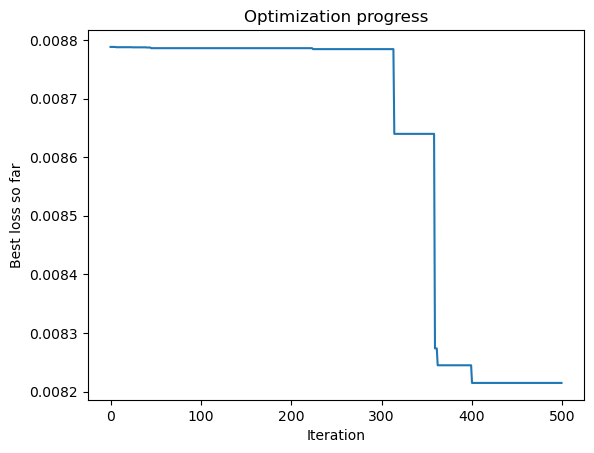

In [124]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

In [126]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_resl = xgb.XGBRegressor(
    objective='reg:squarederror', #N
    random_state=41, #N
    n_estimators=1000, #N
    eta = best_hyperparams_resl['eta'],
    gamma = best_hyperparams_resl['gamma'],
    max_depth = int(best_hyperparams_resl['max_depth']),
    min_child_weight = int(best_hyperparams_resl['min_child_weight']),
    subsample = best_hyperparams_resl['subsample'],
    colsample_bytree = best_hyperparams_resl['colsample_bytree'],
    alpha = best_hyperparams_resl['alpha'],
    reg_lambda = best_hyperparams_resl['reg_lambda']
)


# Fit the model to the training data
xgb_resl.fit(X_train_resl, y_train_resl)

XGBRegressor(alpha=np.float64(1.2171217588231447), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.401181048856649), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.009908186060058045), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.00032733867106400226), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=19, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000, ...)

In [127]:
# Predict on training data
y_pred_resl_train = xgb_resl.predict(X_train_resl)

# Predict on test data
y_pred_resl_test = xgb_resl.predict(X_test_resl)

# Compute R² on both
r2_train = r2_score(y_train_resl, y_pred_resl_train)
r2_test = r2_score(y_test_resl, y_pred_resl_test)

print(r2_train)
print(r2_test)

0.21278432530521074
0.037745861003361414


### B) Resistance

#### Hyperparameter tuning

In [8]:
# Define hyperparameter space
space = {
    'eta': hp.loguniform('eta', np.log(0.001), np.log(0.1)), 
    'gamma': hp.uniform('gamma', 0, 5),  
    'max_depth': hp.quniform('max_depth', 2, 5, 1),  
    'min_child_weight': hp.loguniform('min_child_weight', np.log(3), np.log(30)), 
    'subsample': hp.uniform('subsample', 0.4, 0.8),  
    'colsample_bytree': hp.uniform('colsample_bytree', 0.4, 0.8),  
    'alpha': hp.loguniform('alpha', np.log(0.1), np.log(100)),  
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1), np.log(100))
}


In [9]:
def objective_rest(space):
    # Inner CV for model evaluation
    cv_scores = []
    
    # Manual cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=41)
    
    for train_idx, val_idx in kf.split(X_train_rest):
        X_tr, X_val = X_train_rest.iloc[train_idx], X_train_rest.iloc[val_idx]
        y_tr, y_val = y_train_rest.iloc[train_idx], y_train_rest.iloc[val_idx]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=41,
            eta=space['eta'],
            gamma=space['gamma'],
            max_depth=int(space['max_depth']),
            min_child_weight=int(space['min_child_weight']),
            subsample=space['subsample'],
            colsample_bytree=space['colsample_bytree'],
            alpha=space['alpha'],
            reg_lambda=space['reg_lambda'],
            n_estimators=2000,
            early_stopping_rounds=50
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Predict on validation
        y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration))
        score = mean_squared_error(y_val, y_pred)
        cv_scores.append(score)
    
    return {'loss': np.mean(cv_scores), 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rest = fmin(
    fn = objective_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 500,
    trials = trials,
    rstate = np.random.default_rng(41)
)

  0%|          | 0/500 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 500/500 [19:50<00:00,  2.38s/trial, best loss: 0.07418044036994262]


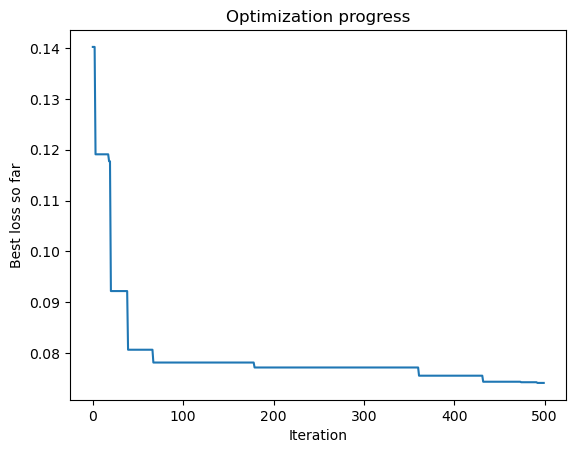

In [10]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

#### Fitting model with tuned parameters

In [ ]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rest = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=41, 
    n_estimators=1000, 
    eta = best_hyperparams_rest['eta'],
    gamma = best_hyperparams_rest['gamma'],
    max_depth = int(best_hyperparams_rest['max_depth']),
    min_child_weight = int(best_hyperparams_rest['min_child_weight']),
    subsample = best_hyperparams_rest['subsample'],
    colsample_bytree = best_hyperparams_rest['colsample_bytree'],
    alpha = best_hyperparams_rest['alpha'],
    reg_lambda = best_hyperparams_rest['reg_lambda']
)


# Fit the model to the training data
xgb_rest.fit(X_train_rest, y_train_rest)

XGBRegressor(alpha=np.float64(0.11582649076666374), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.7554070752816181), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.07053099297433821), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.0025514758509234546), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000, ...)

#### Prediction, model performance

In [13]:
# Predict on training data
y_pred_rest_train = xgb_rest.predict(X_train_rest)

# Predict on test data
y_pred_rest_test = xgb_rest.predict(X_test_rest)

# Compute R² on both
r2_train = r2_score(y_train_rest, y_pred_rest_train)
r2_test = r2_score(y_test_rest, y_pred_rest_test)

print(r2_train)
print(r2_test)

0.9970636888126274
0.8788272826063925


### C) Recovery

#### Hyperparameter tuning

In [24]:
# Define hyperparameter space
space = {
    'eta': hp.loguniform('eta', np.log(0.001), np.log(0.1)), 
    'gamma': hp.uniform('gamma', 0, 5),  
    'max_depth': hp.quniform('max_depth', 2, 7, 1),  
    'min_child_weight': hp.loguniform('min_child_weight', np.log(1), np.log(30)), 
    'subsample': hp.uniform('subsample', 0.4, 0.8),  
    'colsample_bytree': hp.uniform('colsample_bytree', 0.4, 0.8),  
    'alpha': hp.loguniform('alpha', np.log(0.01), np.log(10)),  
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1), np.log(100))
}


In [25]:
def objective_rec(space):
    # Inner CV for model evaluation
    cv_scores = []
    
    # Manual cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=41)
    
    for train_idx, val_idx in kf.split(X_train_rec):
        X_tr, X_val = X_train_rec.iloc[train_idx], X_train_rec.iloc[val_idx]
        y_tr, y_val = y_train_rec.iloc[train_idx], y_train_rec.iloc[val_idx]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=41,
            eta=space['eta'],
            gamma=space['gamma'],
            max_depth=int(space['max_depth']),
            min_child_weight=int(space['min_child_weight']),
            subsample=space['subsample'],
            colsample_bytree=space['colsample_bytree'],
            alpha=space['alpha'],
            reg_lambda=space['reg_lambda'],
            n_estimators=2000,
            early_stopping_rounds=50
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Predict on validation
        y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration))
        score = mean_squared_error(y_val, y_pred)
        cv_scores.append(score)
    
    return {'loss': np.mean(cv_scores), 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rec = fmin(
    fn = objective_rec,
    space=space,
    algo = tpe.suggest,
    max_evals = 500,
    trials = trials,
    rstate = np.random.default_rng(41)
)

  0%|          | 0/500 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 500/500 [37:20<00:00,  4.48s/trial, best loss: 0.2093447170720446]   


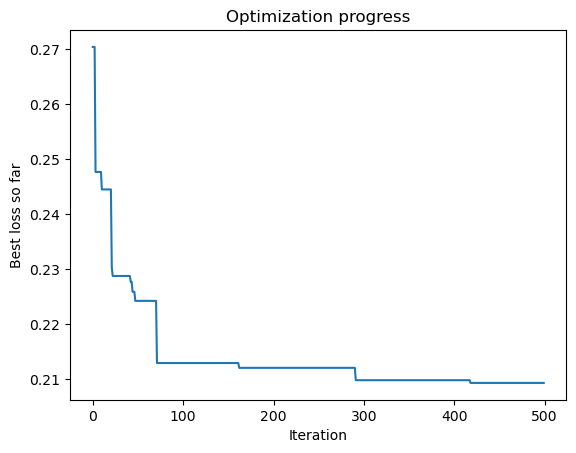

In [26]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

#### Fitting model with tuned parameters

In [28]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rec = xgb.XGBRegressor(
    objective='reg:squarederror', #N
    random_state=41, #N
    n_estimators=1000, #N
    eta = best_hyperparams_rec['eta'],
    gamma = best_hyperparams_rec['gamma'],
    max_depth = int(best_hyperparams_rec['max_depth']),
    min_child_weight = int(best_hyperparams_rec['min_child_weight']),
    subsample = best_hyperparams_rec['subsample'],
    colsample_bytree = best_hyperparams_rec['colsample_bytree'],
    alpha = best_hyperparams_rec['alpha'],
    reg_lambda = best_hyperparams_rec['reg_lambda']
)


# Fit the model to the training data
xgb_rec.fit(X_train_rec, y_train_rec)

XGBRegressor(alpha=np.float64(0.029219189304153806), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.6741991485640005), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.007095637787376167), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.106140105151042), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000, ...)

#### Prediction, model performance

In [29]:
# Predict on training data
y_pred_rec_train = xgb_rec.predict(X_train_rec)

# Predict on test data
y_pred_rec_test = xgb_rec.predict(X_test_rec)

# Compute R² on both
r2_train = r2_score(y_train_rec, y_pred_rec_train)
r2_test = r2_score(y_test_rec, y_pred_rec_test)

print(r2_train)
print(r2_test)

0.9753066524437304
0.7474096417289879


### D) kNDVI anomaly strength

#### Hyperparameter tuning

In [ ]:
space = {
    'eta': hp.loguniform('eta', np.log(0.003), np.log(0.2)),
    'max_depth': hp.quniform('max_depth', 2, 8, 1),
    'min_child_weight': hp.loguniform('min_child_weight', np.log(1), np.log(200)),
    'gamma': hp.loguniform('gamma', np.log(1e-4), np.log(5)),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1.0),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1), np.log(100))
}


In [107]:
def objective_anom(space):
    # Inner CV for model evaluation
    cv_scores = []
    
    # Manual cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=41)
    
    for train_idx, val_idx in kf.split(X_train_anom):
        X_tr, X_val = X_train_anom.iloc[train_idx], X_train_anom.iloc[val_idx]
        y_tr, y_val = y_train_anom.iloc[train_idx], y_train_anom.iloc[val_idx]
        
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=41,
            eta=space['eta'],
            gamma=space['gamma'],
            max_depth=int(space['max_depth']),
            min_child_weight=int(space['min_child_weight']),
            subsample=space['subsample'],
            colsample_bytree=space['colsample_bytree'],
            alpha=space['alpha'],
            reg_lambda=space['reg_lambda'],
            n_estimators=2000,
            early_stopping_rounds=50
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Predict on validation
        y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration))
        score = mean_squared_error(y_val, y_pred)
        cv_scores.append(score)
    
    return {'loss': np.mean(cv_scores), 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_anom = fmin(
    fn = objective_anom,
    space=space,
    algo = tpe.suggest,
    max_evals = 500,
    trials = trials,
    rstate = np.random.default_rng(41)
)

100%|██████████| 500/500 [08:58<00:00,  1.08s/trial, best loss: 0.000509950504336521] 


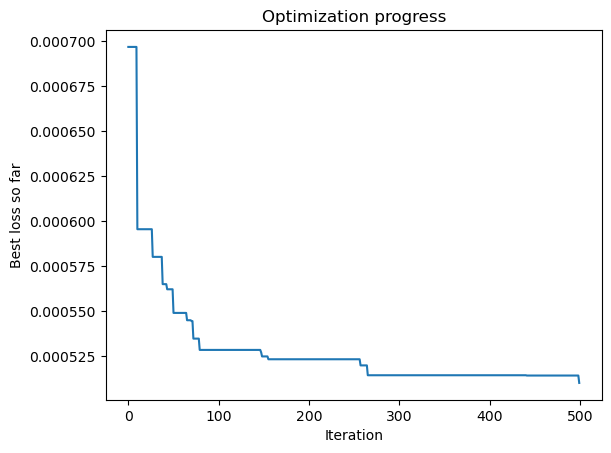

In [108]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

#### Fitting model with tuned parameters

In [109]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_anom = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=41, 
    n_estimators=1000, 
    eta = best_hyperparams_anom['eta'],
    gamma = best_hyperparams_anom['gamma'],
    max_depth = int(best_hyperparams_anom['max_depth']),
    min_child_weight = int(best_hyperparams_anom['min_child_weight']),
    subsample = best_hyperparams_anom['subsample'],
    colsample_bytree = best_hyperparams_anom['colsample_bytree'],
    alpha = best_hyperparams_anom['alpha'],
    reg_lambda = best_hyperparams_anom['reg_lambda']
)


# Fit the model to the training data
xgb_anom.fit(X_train_anom, y_train_anom)

XGBRegressor(alpha=np.float64(0.0010168891951616253), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.9154924152917577), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.11721304121120622), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.0001259158740824058), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000, ...)

#### Prediction, model performance

In [110]:
# Predict on training data
y_pred_anom_train = xgb_anom.predict(X_train_anom)

# Predict on the test set
y_pred_anom_test = xgb_anom.predict(X_test_anom)

# Compute R² on both
r2_train = r2_score(y_train_anom, y_pred_anom_train)
r2_test = r2_score(y_test_anom, y_pred_anom_test)

print(r2_train)
print(r2_test)

0.9785610711411489
0.4381577624640759


## 2. Feature importance
### A) Resilience

In [140]:
explainer_resl = shap.Explainer(xgb_resl)
shap_values_resl = explainer_resl(X_test_resl)
shap.initjs() # Initializes havascript support

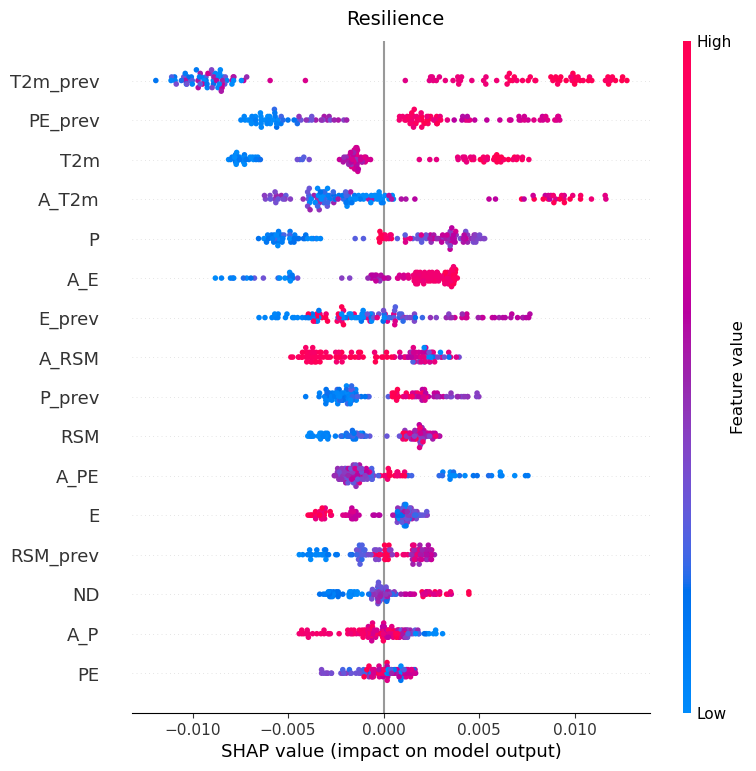

In [141]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_resl, X_test_resl, show=False)
plt.suptitle("Resilience", fontsize=14, y=0.97)
plt.tight_layout()

# Export figure
output_path = '../document/Images/bees_resl.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')


plt.show()

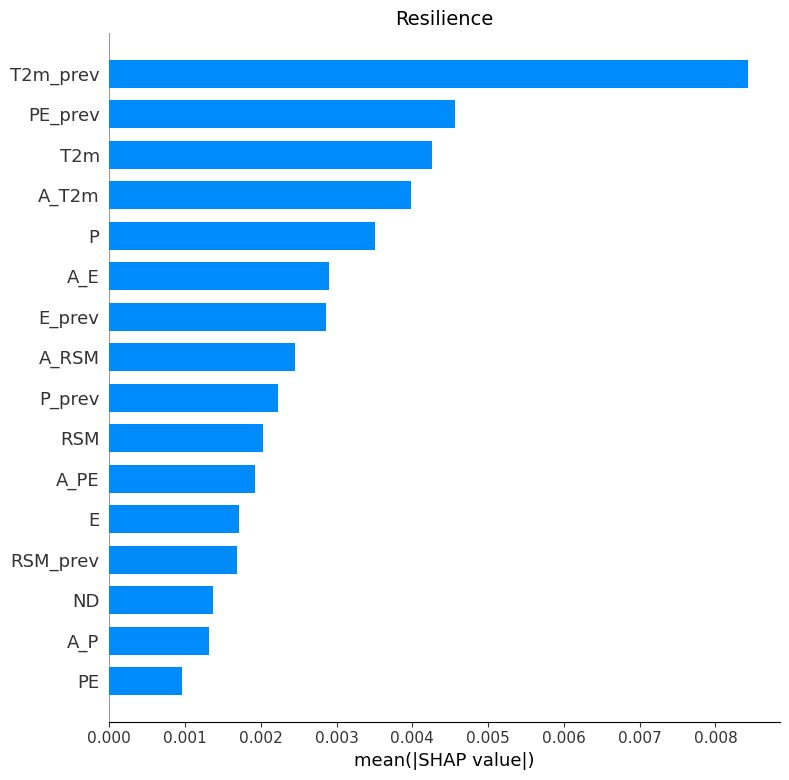

In [142]:
shap.summary_plot(shap_values_resl, X_test_resl, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resilience", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()

# Export figure
output_path = '../document/Images/bar_resl.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

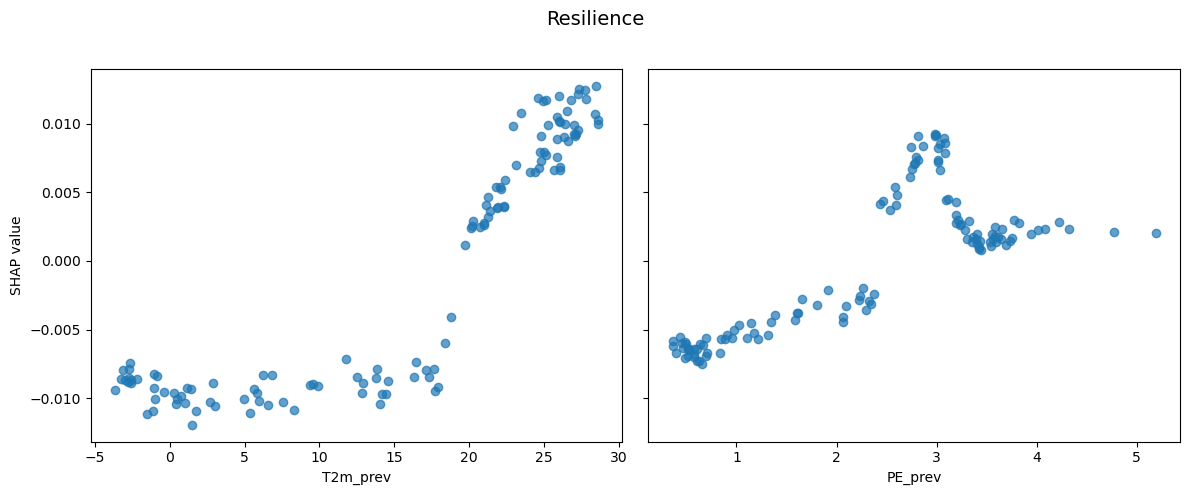

In [143]:
variable1 = 'T2m_prev'
variable2 = 'PE_prev'

# Extract SHAP values
shap_v1 = shap_values_resl[:, variable1].values
shap_v2 = shap_values_resl[:, variable2].values

# Extract feature values
feat_v1 = X_test_resl[variable1].values
feat_v2 = X_test_resl[variable2].values

# Create side-by-side plots with shared y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Shared title
fig.suptitle("Resilience", fontsize=14)

# Plot variable 1
ax[0].scatter(feat_v1, shap_v1, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

# Plot variable 2
ax[1].scatter(feat_v2, shap_v2, alpha=0.7)
ax[1].set_xlabel(variable2)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Export figure
output_path = '../document/Images/relat_resl.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')


plt.show()


### B) Resistance

In [16]:
explainer_rest = shap.Explainer(xgb_rest)
shap_values_rest = explainer_rest(X_test_rest)

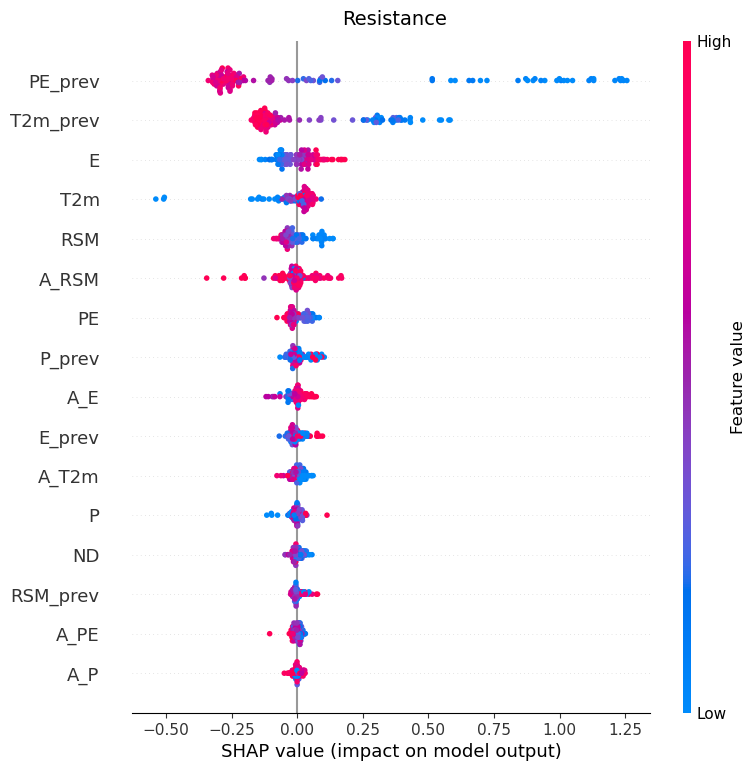

In [17]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rest, X_test_rest, show=False)
plt.suptitle("Resistance", fontsize=14, y=0.97)
plt.tight_layout()

# Export figure
output_path = '../document/Images/bees_rest.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

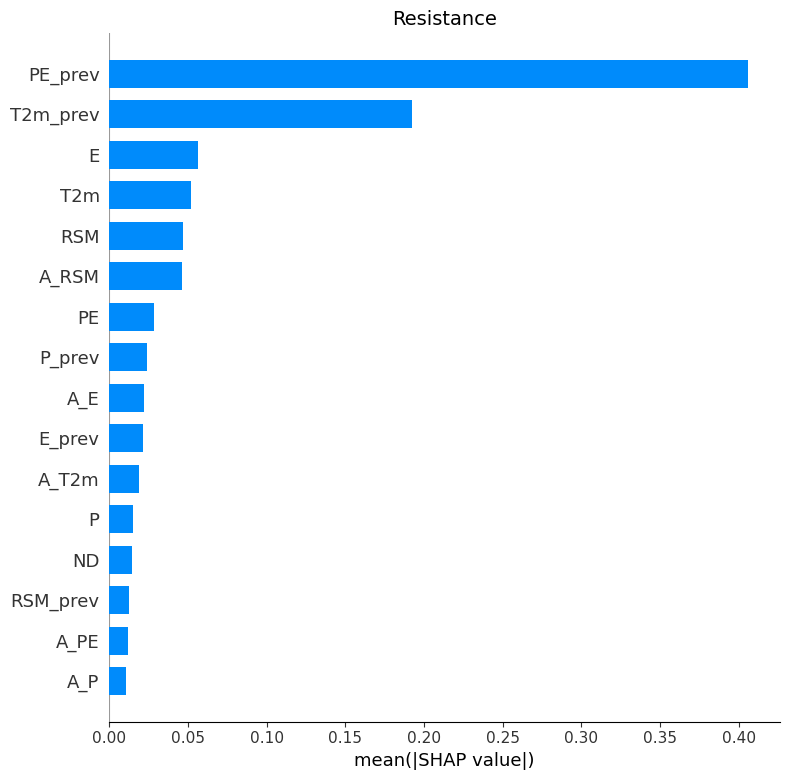

In [18]:
# Create SHAP summary plot
shap.summary_plot(shap_values_rest, X_test_rest, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resistance", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()

# Export figure
output_path = '../document/Images/bar_rest.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()


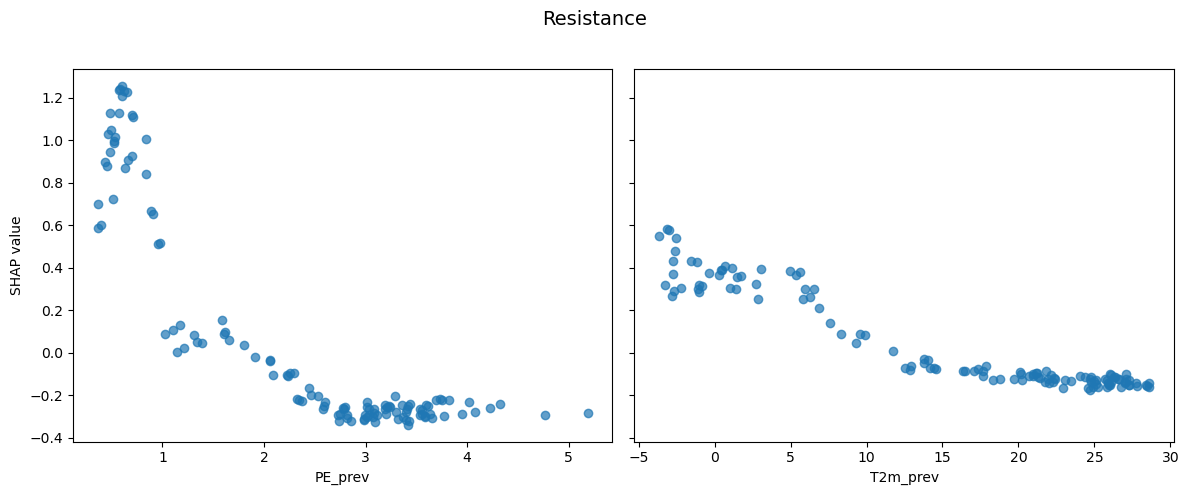

In [19]:
variable1 = 'PE_prev'
variable2 = 'T2m_prev'

# Extract SHAP values
shap_v1 = shap_values_rest[:, variable1].values
shap_v2 = shap_values_rest[:, variable2].values

# Extract feature values
feat_v1 = X_test_rest[variable1].values
feat_v2 = X_test_rest[variable2].values

# Create side-by-side plots with shared y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Shared title
fig.suptitle("Resistance", fontsize=14)

# Plot variable 1
ax[0].scatter(feat_v1, shap_v1, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

# Plot variable 2
ax[1].scatter(feat_v2, shap_v2, alpha=0.7)
ax[1].set_xlabel(variable2)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_rest.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
# First, get the vegetation classes for the test set
test_indices_rest = X_test_rest.index
veg_classes_rest = df.loc[test_indices_rest, 'veg_class']

# Define mappings
trait_group_mapping = {
    # Group A: Forests
    1: 'Forest', 
    2: 'Forest', 
    3: 'Forest', 
    4: 'Forest', 
    5: 'Forest', 
    8: 'Forest', 
    18: 'Forest',
    
    # Group B: Shrublands & Grasslands
    6: 'Shrub/Grass',
    7: 'Shrub/Grass', 
    9: 'Shrub/Grass', 
    10: 'Shrub/Grass', 
    19: 'Shrub/Grass', 
    20: 'Shrub/Grass',
    
    # Group C: Human-Impacted
    12: 'Human/Agricultural', 
    13: 'Urban', 
    14: 'Mosaic',
    
    # Group D: Wetlands & Water
    11: 'Wetland', 
    17: 'Water',
    
    # Group E: Non-Vegetated
    15: 'Ice/Snow', 
    16: 'Barren'
}

climate_group_mapping = {
    # Boreal/Cold Climate
    1: 'Boreal/Cold',      # Evergreen Needleleaf Forest
    3: 'Boreal/Cold',      # Deciduous Needleleaf Forest
    18: 'Boreal/Cold',     # Wooded Tundra
    19: 'Boreal/Cold',     # Mixed Tundra
    20: 'Boreal/Cold',     # Bare Ground Tundra
    15: 'Boreal/Cold',     # Snow and Ice
    
    # Temperate Climate
    4: 'Temperate',        # Deciduous Broadleaf Forest
    5: 'Temperate',        # Mixed Forest
    10: 'Temperate',       # Grassland
    12: 'Temperate',       # Cropland
    14: 'Temperate',       # Cropland/Natural Vegetation Mosaic
    
    # Tropical/Subtropical
    2: 'Tropical',         # Evergreen Broadleaf Forest
    8: 'Tropical',         # Woody Savannas
    9: 'Tropical',         # Savannas
    
    # Arid/Semi-Arid
    6: 'Arid',             # Closed Shrublands
    7: 'Arid',             # Open Shrublands
    16: 'Arid',            # Barren or Sparsely Vegetated
    
    # Other/Special
    11: 'Wetland',         # Permanent Wetland
    13: 'Urban',           # Urban and Built-Up
    17: 'Ocean'            # Ocean
}

# Create group labels
def get_trait_group(veg_class):
    return trait_group_mapping.get(veg_class, 'Unknown')

def get_climate_group(veg_class):
    return climate_group_mapping.get(veg_class, 'Unknown')

trait_groups = veg_classes_rest.apply(get_trait_group)
climate_groups = veg_classes_rest.apply(get_climate_group)


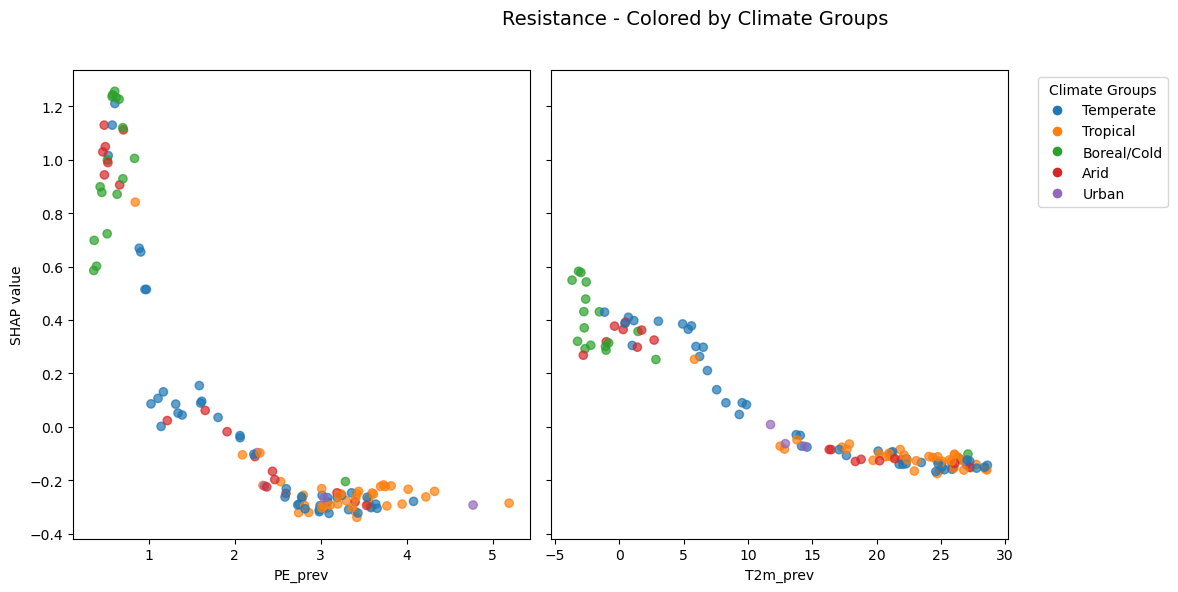

In [33]:
# Variables to plot
variable1 = 'PE_prev'
variable2 = 'T2m_prev'

# Extract SHAP values
shap_v1 = shap_values_rest[:, variable1].values
shap_v2 = shap_values_rest[:, variable2].values

# Extract feature values
feat_v1 = X_test_rest[variable1].values
feat_v2 = X_test_rest[variable2].values

# Define fixed colors for each climate group
climate_color_map = {
    'Temperate': '#1f77b4',
    'Tropical': '#ff7f0e',
    'Boreal/Cold': '#2ca02c',
    'Arid': '#d62728',
    'Urban': '#9467bd'
}

# Map colors to each sample
colors = climate_groups.map(climate_color_map)

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Resistance - Colored by Climate Groups", fontsize=14)

# Scatter plots
ax[0].scatter(feat_v1, shap_v1, c=colors, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

ax[1].scatter(feat_v2, shap_v2, c=colors, alpha=0.7)
ax[1].set_xlabel(variable2)

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=8)
    for color in climate_color_map.values()
]

ax[1].legend(handles, climate_color_map.keys(),
             title="Climate Groups",
             bbox_to_anchor=(1.05, 1),
             loc="upper left")

plt.tight_layout(rect=[0,0,0.85,0.96])
plt.show()

### C) Recovery

In [35]:
explainer_rec = shap.Explainer(xgb_rec)
shap_values_rec = explainer_rec(X_test_rec)

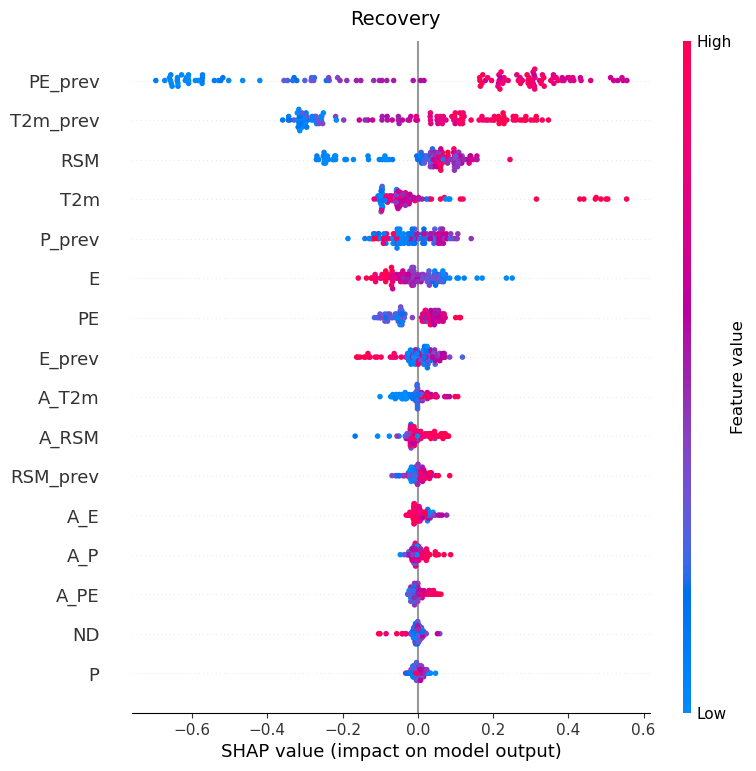

In [36]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rec, X_test_rec, show=False)
plt.suptitle("Recovery", fontsize=14, y=0.97)
plt.tight_layout()

# Export figure
output_path = '../document/Images/bees_rec.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

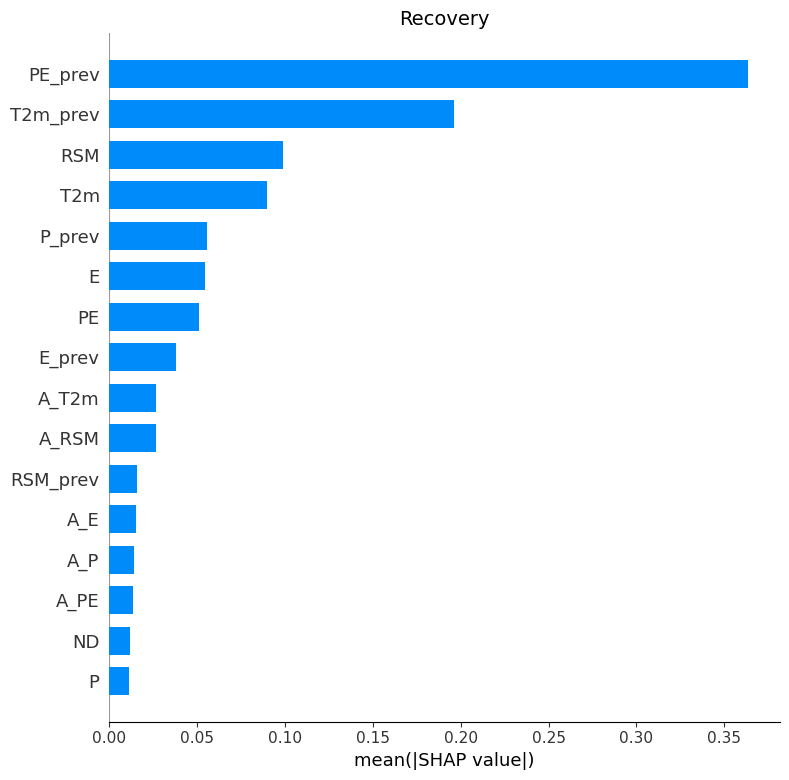

In [37]:
shap.summary_plot(shap_values_rec, X_test_rec, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Recovery", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()

# Export figure
output_path = '../document/Images/bar_rec.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

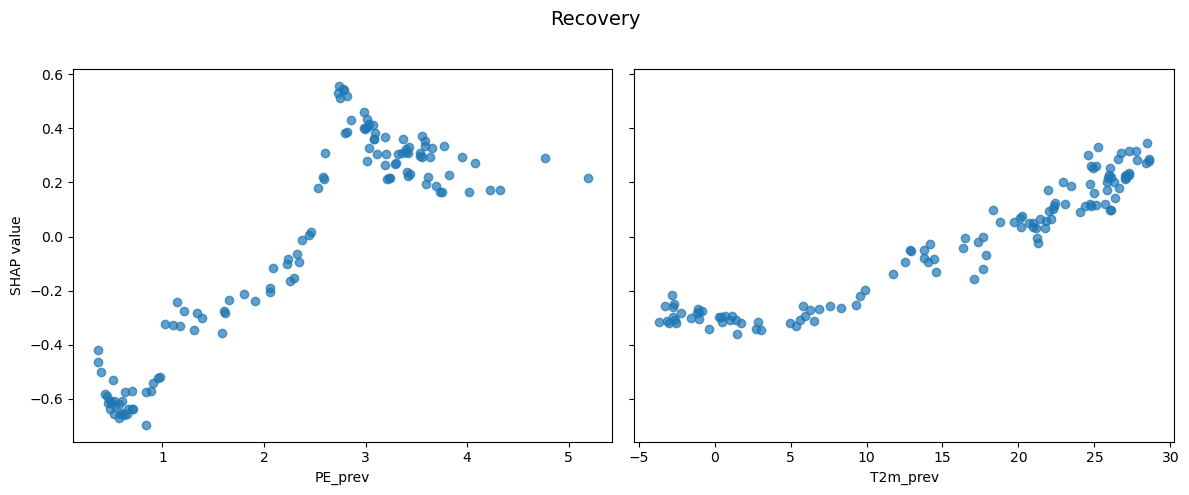

In [38]:
variable1 = 'PE_prev'
variable2 = 'T2m_prev'

# Extract SHAP values
shap_v1 = shap_values_rec[:, variable1].values
shap_v2 = shap_values_rec[:, variable2].values

# Extract feature values
feat_v1 = X_test_rec[variable1].values
feat_v2 = X_test_rec[variable2].values

# Create side-by-side plots with shared y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Shared title
fig.suptitle("Recovery", fontsize=14)

# Plot variable 1
ax[0].scatter(feat_v1, shap_v1, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

# Plot variable 2
ax[1].scatter(feat_v2, shap_v2, alpha=0.7)
ax[1].set_xlabel(variable2)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_rec.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()


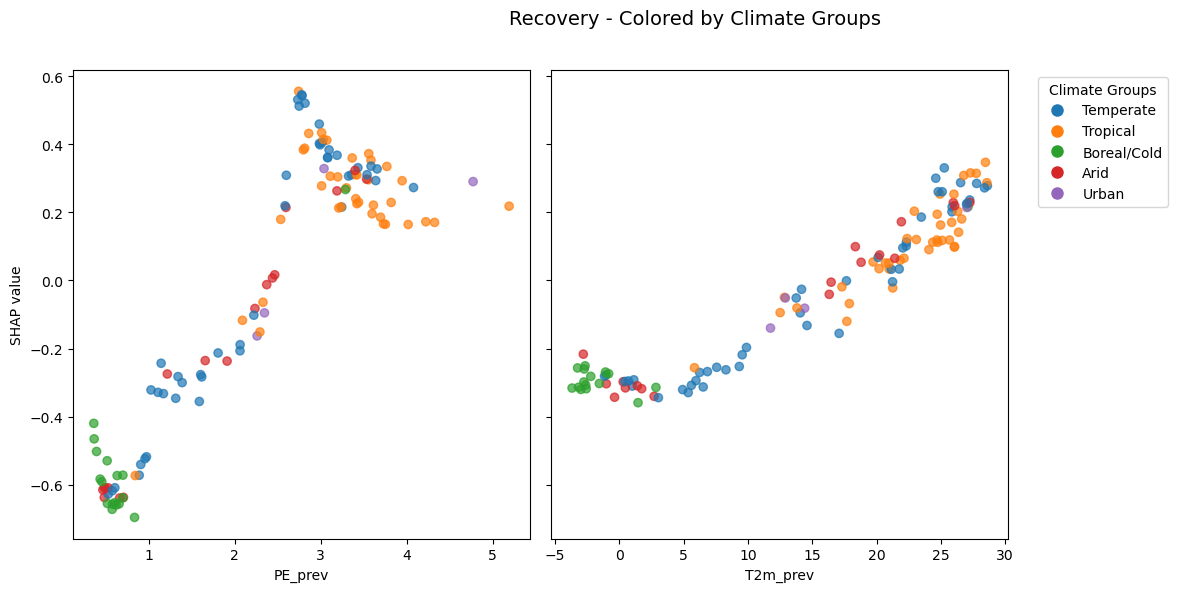

In [40]:
# Variables to plot
variable1 = 'PE_prev'
variable2 = 'T2m_prev'

# Extract SHAP values
shap_v1 = shap_values_rec[:, variable1].values
shap_v2 = shap_values_rec[:, variable2].values

# Extract feature values
feat_v1 = X_test_rec[variable1].values
feat_v2 = X_test_rec[variable2].values

# Define fixed colors for each climate group
climate_color_map = {
    'Temperate': '#1f77b4',
    'Tropical': '#ff7f0e',
    'Boreal/Cold': '#2ca02c',
    'Arid': '#d62728',
    'Urban': '#9467bd'
}

# Map colors to each sample
colors = climate_groups.map(climate_color_map)

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Recovery - Colored by Climate Groups", fontsize=14)

# Scatter plots
ax[0].scatter(feat_v1, shap_v1, c=colors, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

ax[1].scatter(feat_v2, shap_v2, c=colors, alpha=0.7)
ax[1].set_xlabel(variable2)

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color, markersize=8)
    for color in climate_color_map.values()
]

ax[1].legend(handles, climate_color_map.keys(),
             title="Climate Groups",
             bbox_to_anchor=(1.05, 1),
             loc="upper left")

plt.tight_layout(rect=[0,0,0.85,0.96])
plt.show()

### D) Anomaly

In [152]:
explainer_anom = shap.Explainer(xgb_anom)
shap_values_anom = explainer_anom(X_test_anom)

Global overview of feature impact per observation:

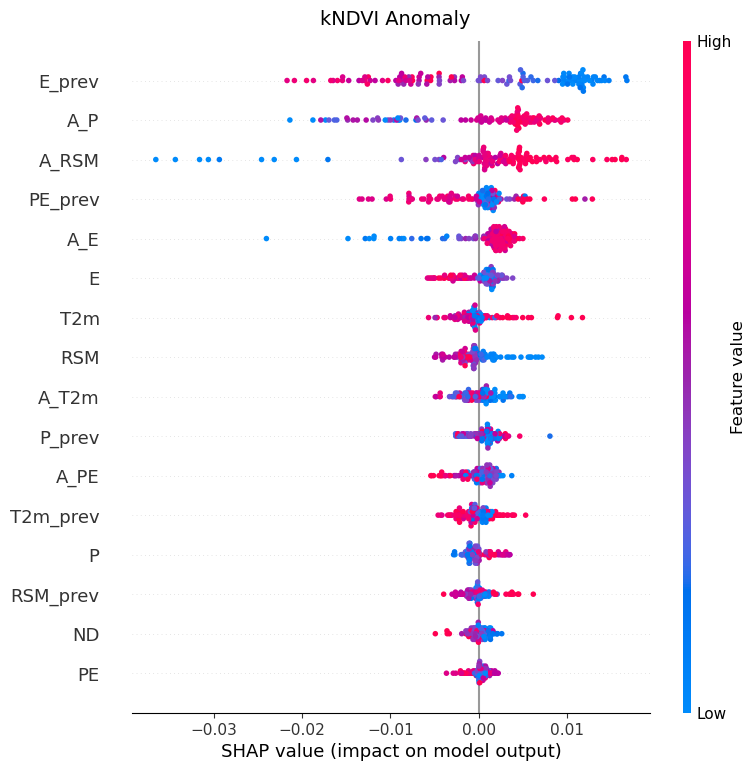

In [153]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_anom, X_test_anom, show=False)
plt.suptitle("kNDVI Anomaly", fontsize=14, y=0.97)
plt.tight_layout()

# Export figure
output_path = '../document/Images/bees_anom.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

Average feature impact across dataset:

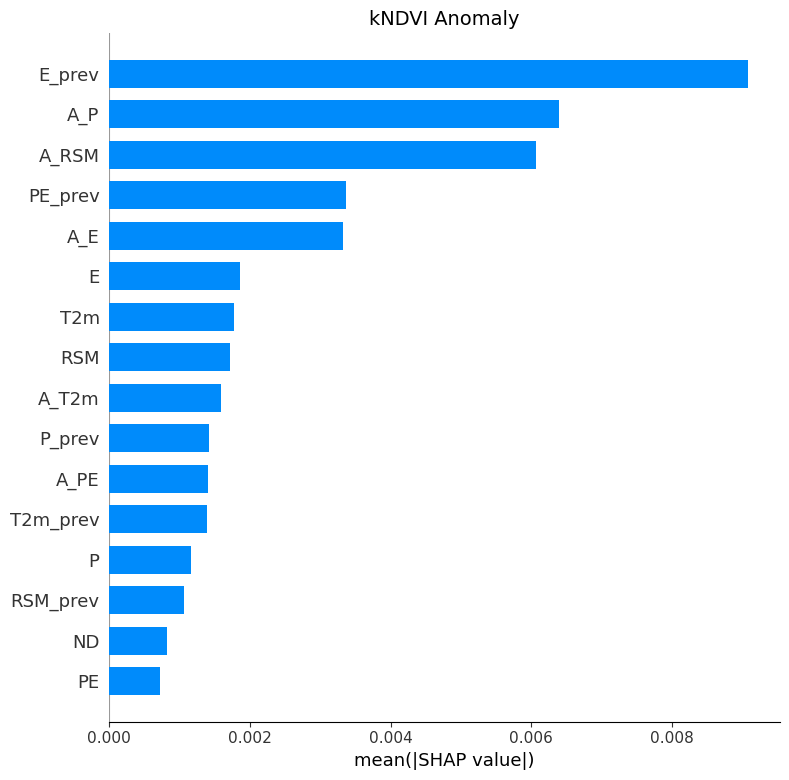

In [154]:
shap.summary_plot(shap_values_anom, X_test_anom, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("kNDVI Anomaly", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()

# Export figure
output_path = '../document/Images/bar_anom.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

Dependence plot of most important feature:

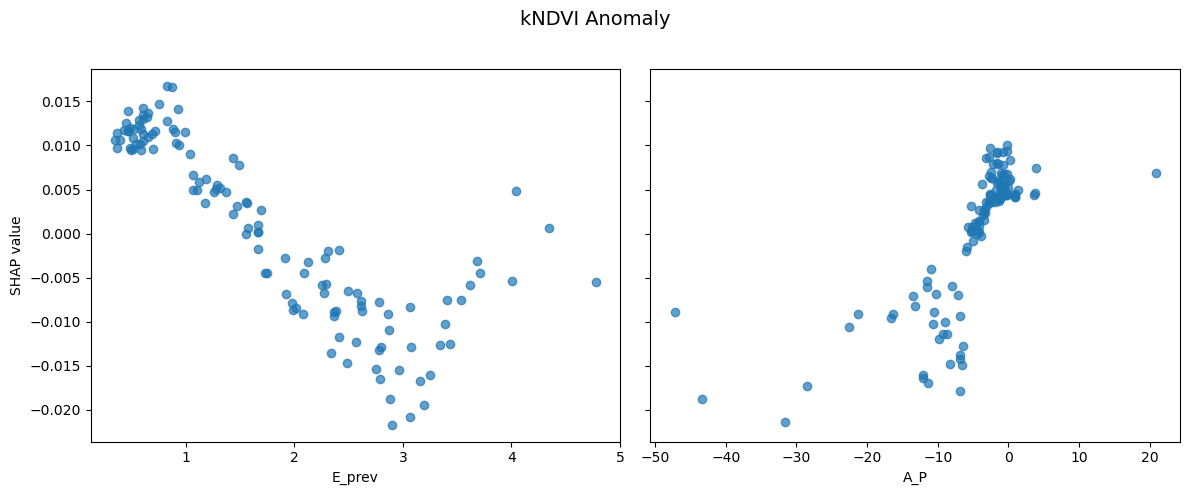

In [160]:
variable1 = 'E_prev'
variable2 = 'A_P'

# Extract SHAP values
shap_v1 = shap_values_anom[:, variable1].values
shap_v2 = shap_values_anom[:, variable2].values

# Extract feature values
feat_v1 = X_test_anom[variable1].values
feat_v2 = X_test_anom[variable2].values

# Create side-by-side plots with shared y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Shared title
fig.suptitle("kNDVI Anomaly", fontsize=14)

# Plot variable 1
ax[0].scatter(feat_v1, shap_v1, alpha=0.7)
ax[0].set_xlabel(variable1)
ax[0].set_ylabel("SHAP value")

# Plot variable 2
ax[1].scatter(feat_v2, shap_v2, alpha=0.7)
ax[1].set_xlabel(variable2)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_anom.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()


# All dependence plots in one figure for Appendix
## Resilience

Features sorted by importance:
  T2m_prev: 0.0084
  PE_prev: 0.0046
  T2m: 0.0043
  A_T2m: 0.0040
  P: 0.0035
  A_E: 0.0029
  E_prev: 0.0029
  A_RSM: 0.0025
  P_prev: 0.0022
  RSM: 0.0020
  A_PE: 0.0019
  E: 0.0017
  RSM_prev: 0.0017
  ND: 0.0014
  A_P: 0.0013
  PE: 0.0010


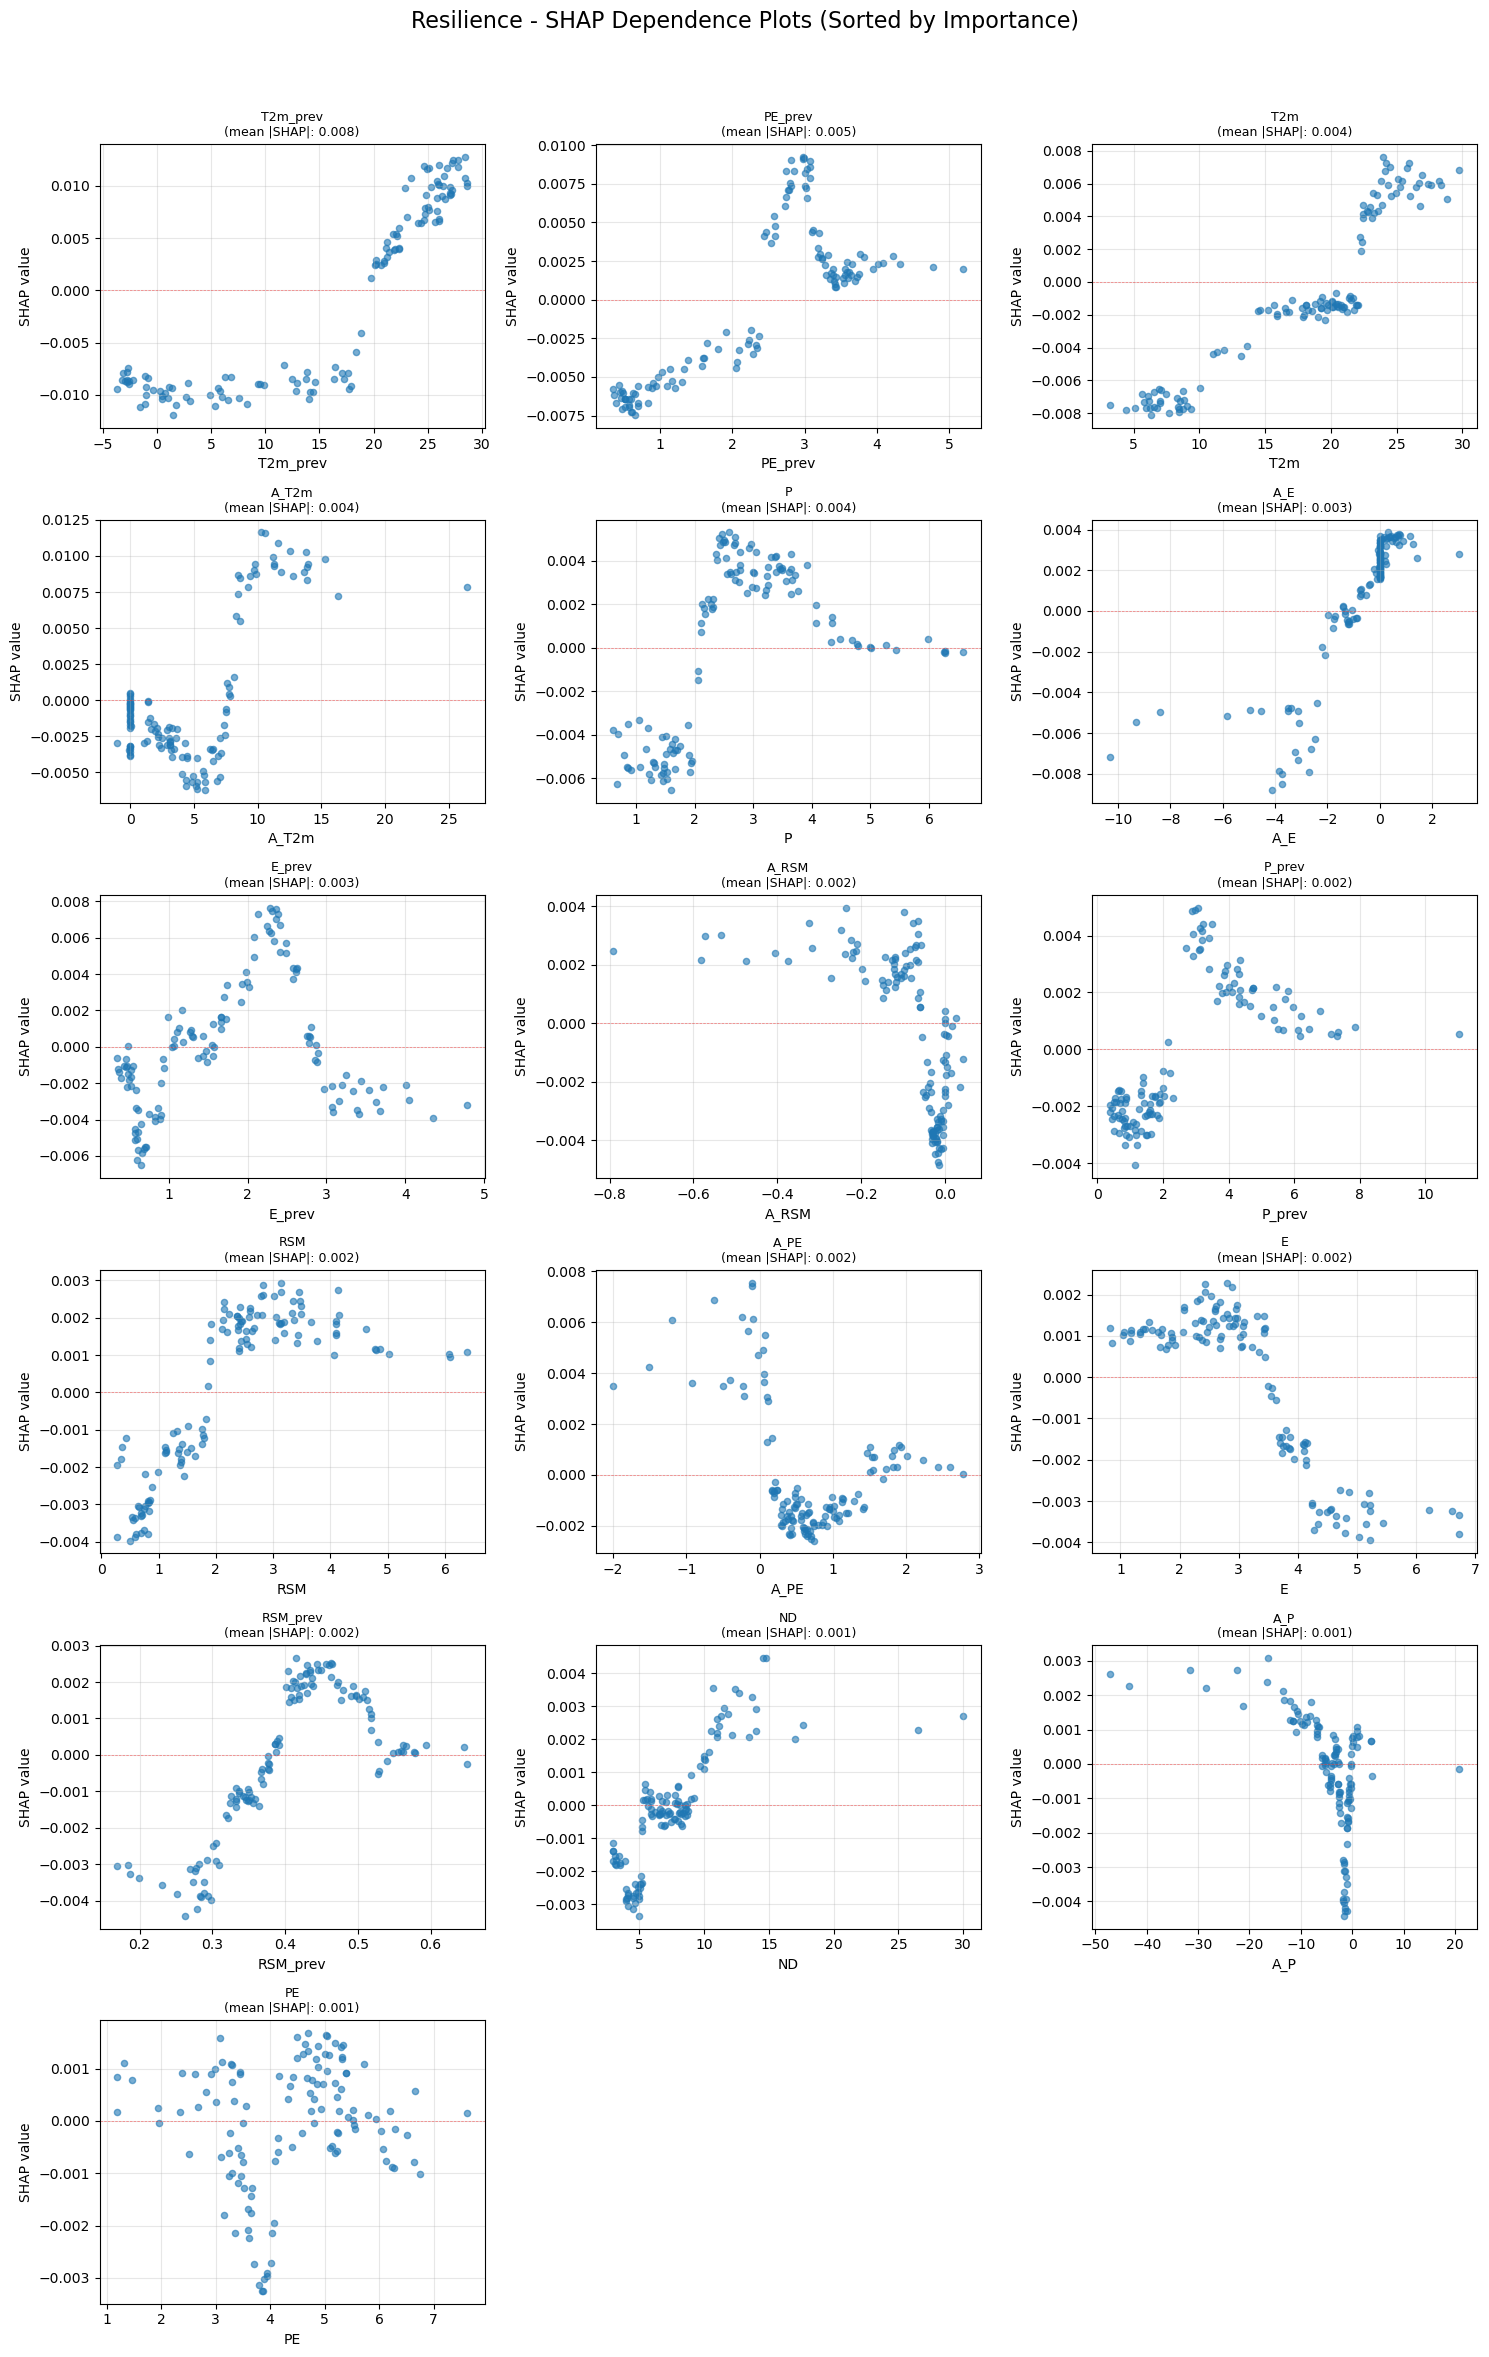

In [156]:

# Get feature names from X_test_resl
feature_names = X_test_resl.columns.tolist()

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = {}
for feature in feature_names:
    # Get feature index
    idx = feature_names.index(feature)
    # Calculate mean absolute SHAP value
    mean_abs = np.abs(shap_values_resl[:, idx].values).mean()
    mean_abs_shap[feature] = mean_abs

# Sort features by mean absolute SHAP value (descending)
sorted_features = sorted(mean_abs_shap.items(), key=lambda x: x[1], reverse=True)
feature_names_sorted = [f[0] for f in sorted_features]
shap_importance = [f[1] for f in sorted_features]

print("Features sorted by importance:")
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")

# Determine grid size for subplots
n_features = len(feature_names_sorted)
n_cols = 3  # Number of columns in the grid
n_rows = ceil(n_features / n_cols)

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
fig.suptitle("Resilience - SHAP Dependence Plots (Sorted by Importance)", fontsize=16)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create dependence plot for each feature
for i, feature in enumerate(feature_names_sorted):
    # Get feature index
    idx = feature_names.index(feature)
    
    # Extract SHAP values and feature values
    shap_values_feature = shap_values_resl[:, idx].values
    feature_values = X_test_resl[feature].values
    
    # Create scatter plot
    axes[i].scatter(feature_values, shap_values_feature, alpha=0.6, s=20)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("SHAP value", fontsize=10)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add importance score as title
    importance = mean_abs_shap[feature]
    axes[i].set_title(f"{feature}\n(mean |SHAP|: {importance:.3f})", fontsize=9)
    
    # Add grid for better readability
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_resl_all.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

## Recovery

Features sorted by importance:
  PE_prev: 0.3635
  T2m_prev: 0.1963
  RSM: 0.0988
  T2m: 0.0896
  P_prev: 0.0555
  E: 0.0545
  PE: 0.0510
  E_prev: 0.0382
  A_T2m: 0.0267
  A_RSM: 0.0264
  RSM_prev: 0.0159
  A_E: 0.0152
  A_P: 0.0139
  A_PE: 0.0137
  ND: 0.0115
  P: 0.0110


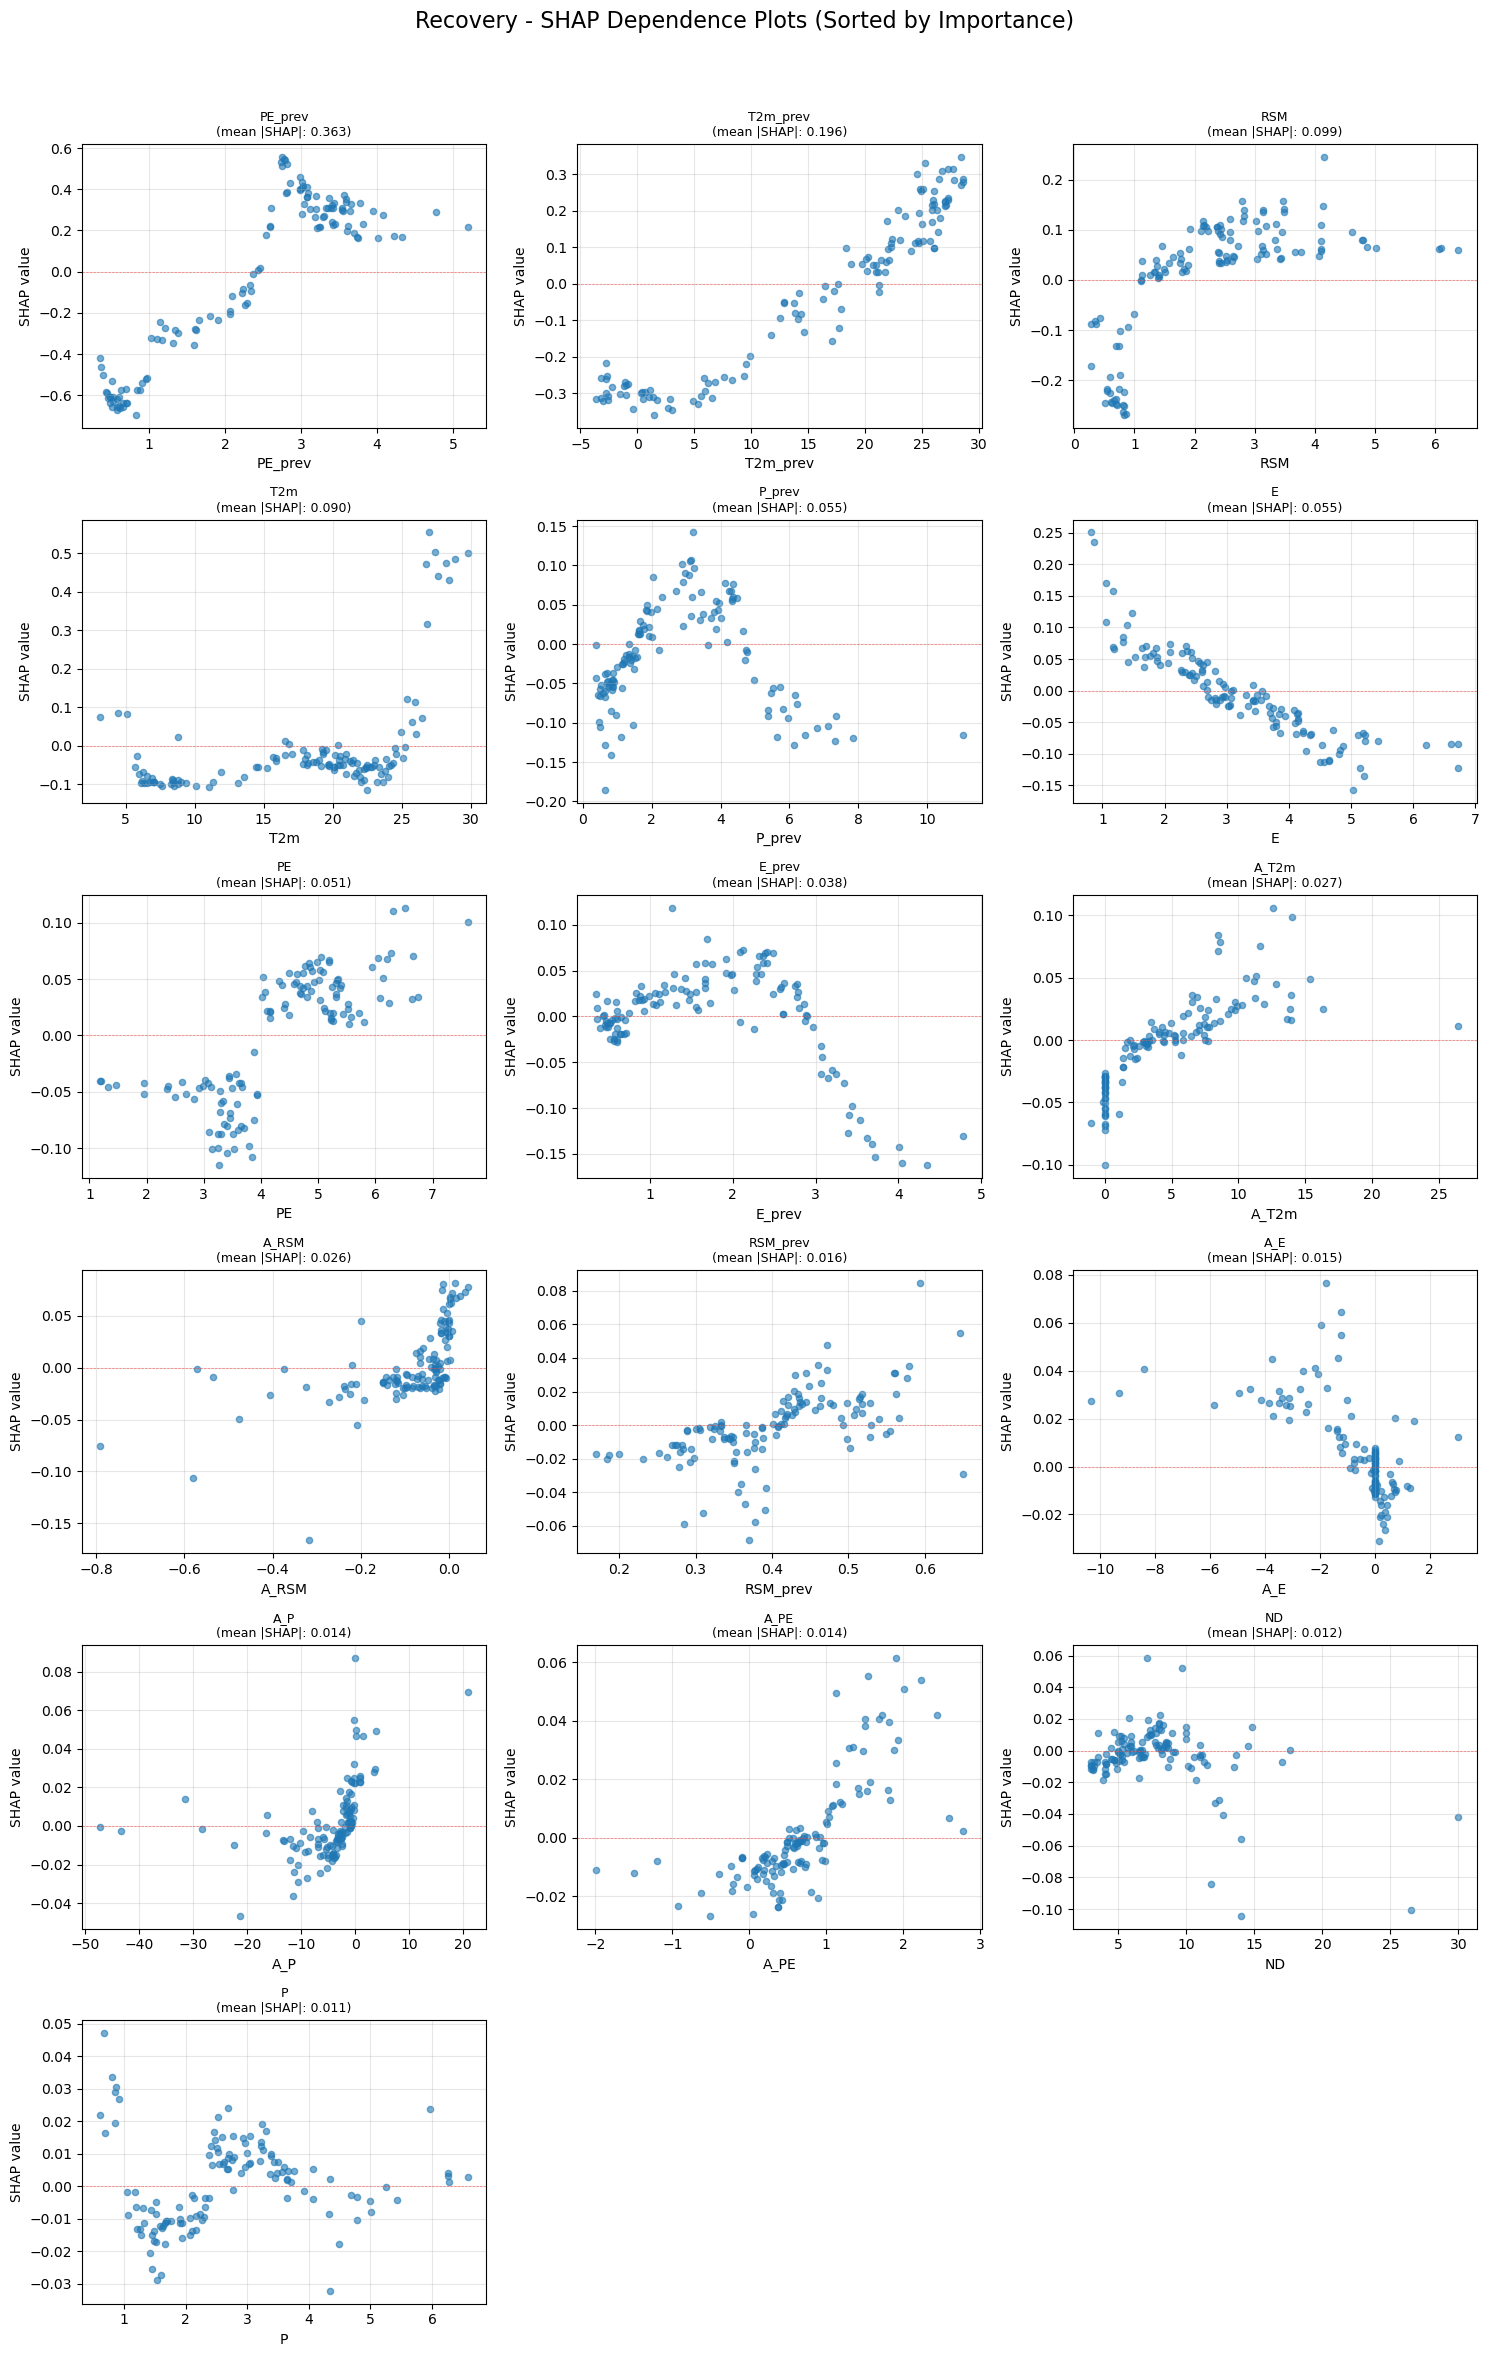

In [157]:
# Get feature names from X_test_rest
feature_names = X_test_rec.columns.tolist()

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = {}
for feature in feature_names:
    # Get feature index
    idx = feature_names.index(feature)
    # Calculate mean absolute SHAP value
    mean_abs = np.abs(shap_values_rec[:, idx].values).mean()
    mean_abs_shap[feature] = mean_abs

# Sort features by mean absolute SHAP value (descending)
sorted_features = sorted(mean_abs_shap.items(), key=lambda x: x[1], reverse=True)
feature_names_sorted = [f[0] for f in sorted_features]
shap_importance = [f[1] for f in sorted_features]

print("Features sorted by importance:")
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")

# Determine grid size for subplots
n_features = len(feature_names_sorted)
n_cols = 3  # Number of columns in the grid
n_rows = ceil(n_features / n_cols)

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
fig.suptitle("Recovery - SHAP Dependence Plots (Sorted by Importance)", fontsize=16)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create dependence plot for each feature
for i, feature in enumerate(feature_names_sorted):
    # Get feature index
    idx = feature_names.index(feature)
    
    # Extract SHAP values and feature values
    shap_values_feature = shap_values_rec[:, idx].values
    feature_values = X_test_rec[feature].values
    
    # Create scatter plot
    axes[i].scatter(feature_values, shap_values_feature, alpha=0.6, s=20)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("SHAP value", fontsize=10)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add importance score as title
    importance = mean_abs_shap[feature]
    axes[i].set_title(f"{feature}\n(mean |SHAP|: {importance:.3f})", fontsize=9)
    
    # Add grid for better readability
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_rec_all.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

## Resistance

Features sorted by importance:
  PE_prev: 0.4060
  T2m_prev: 0.1926
  E: 0.0567
  T2m: 0.0516
  RSM: 0.0465
  A_RSM: 0.0464
  PE: 0.0283
  P_prev: 0.0242
  A_E: 0.0218
  E_prev: 0.0211
  A_T2m: 0.0186
  P: 0.0151
  ND: 0.0143
  RSM_prev: 0.0125
  A_PE: 0.0120
  A_P: 0.0109


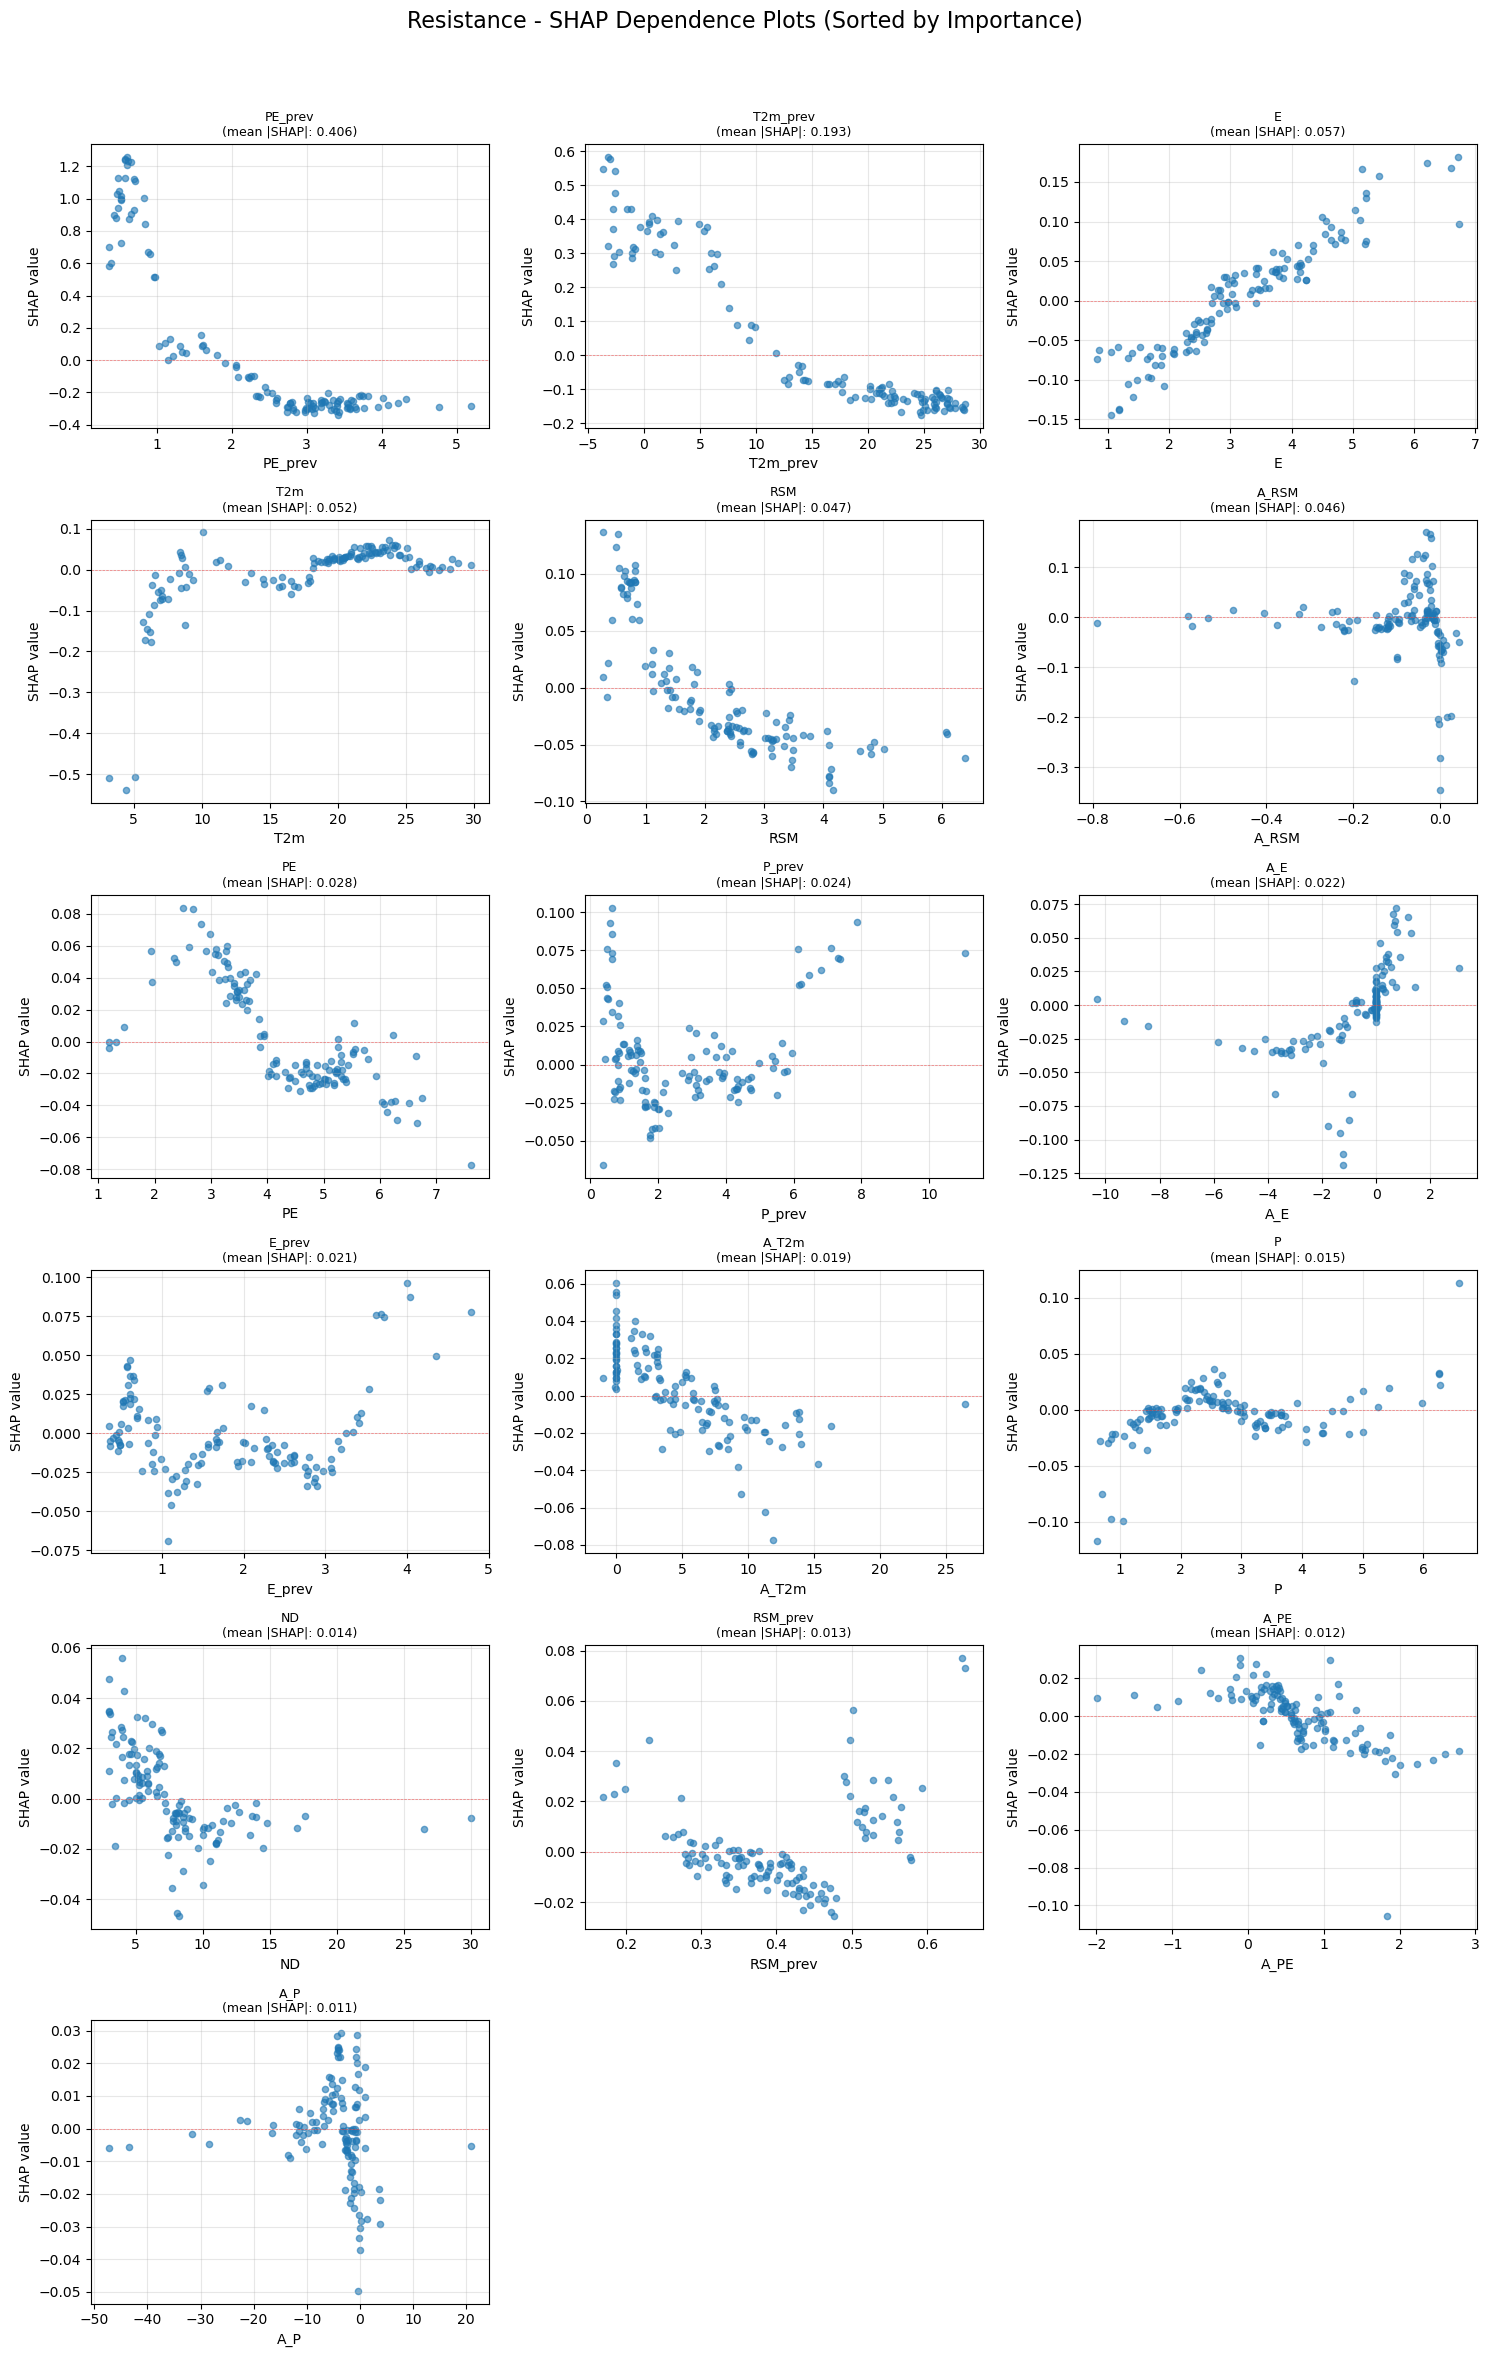

In [158]:

# Get feature names from X_test_rest
feature_names = X_test_rest.columns.tolist()

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = {}
for feature in feature_names:
    # Get feature index
    idx = feature_names.index(feature)
    # Calculate mean absolute SHAP value
    mean_abs = np.abs(shap_values_rest[:, idx].values).mean()
    mean_abs_shap[feature] = mean_abs

# Sort features by mean absolute SHAP value (descending)
sorted_features = sorted(mean_abs_shap.items(), key=lambda x: x[1], reverse=True)
feature_names_sorted = [f[0] for f in sorted_features]
shap_importance = [f[1] for f in sorted_features]

print("Features sorted by importance:")
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")

# Determine grid size for subplots
n_features = len(feature_names_sorted)
n_cols = 3  # Number of columns in the grid
n_rows = ceil(n_features / n_cols)

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
fig.suptitle("Resistance - SHAP Dependence Plots (Sorted by Importance)", fontsize=16)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create dependence plot for each feature
for i, feature in enumerate(feature_names_sorted):
    # Get feature index
    idx = feature_names.index(feature)
    
    # Extract SHAP values and feature values
    shap_values_feature = shap_values_rest[:, idx].values
    feature_values = X_test_rest[feature].values
    
    # Create scatter plot
    axes[i].scatter(feature_values, shap_values_feature, alpha=0.6, s=20)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("SHAP value", fontsize=10)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add importance score as title
    importance = mean_abs_shap[feature]
    axes[i].set_title(f"{feature}\n(mean |SHAP|: {importance:.3f})", fontsize=9)
    
    # Add grid for better readability
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_rest_all.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

## Anomaly

Features sorted by importance:
  E_prev: 0.0091
  A_P: 0.0064
  A_RSM: 0.0061
  PE_prev: 0.0034
  A_E: 0.0033
  E: 0.0019
  T2m: 0.0018
  RSM: 0.0017
  A_T2m: 0.0016
  P_prev: 0.0014
  A_PE: 0.0014
  T2m_prev: 0.0014
  P: 0.0012
  RSM_prev: 0.0011
  ND: 0.0008
  PE: 0.0007


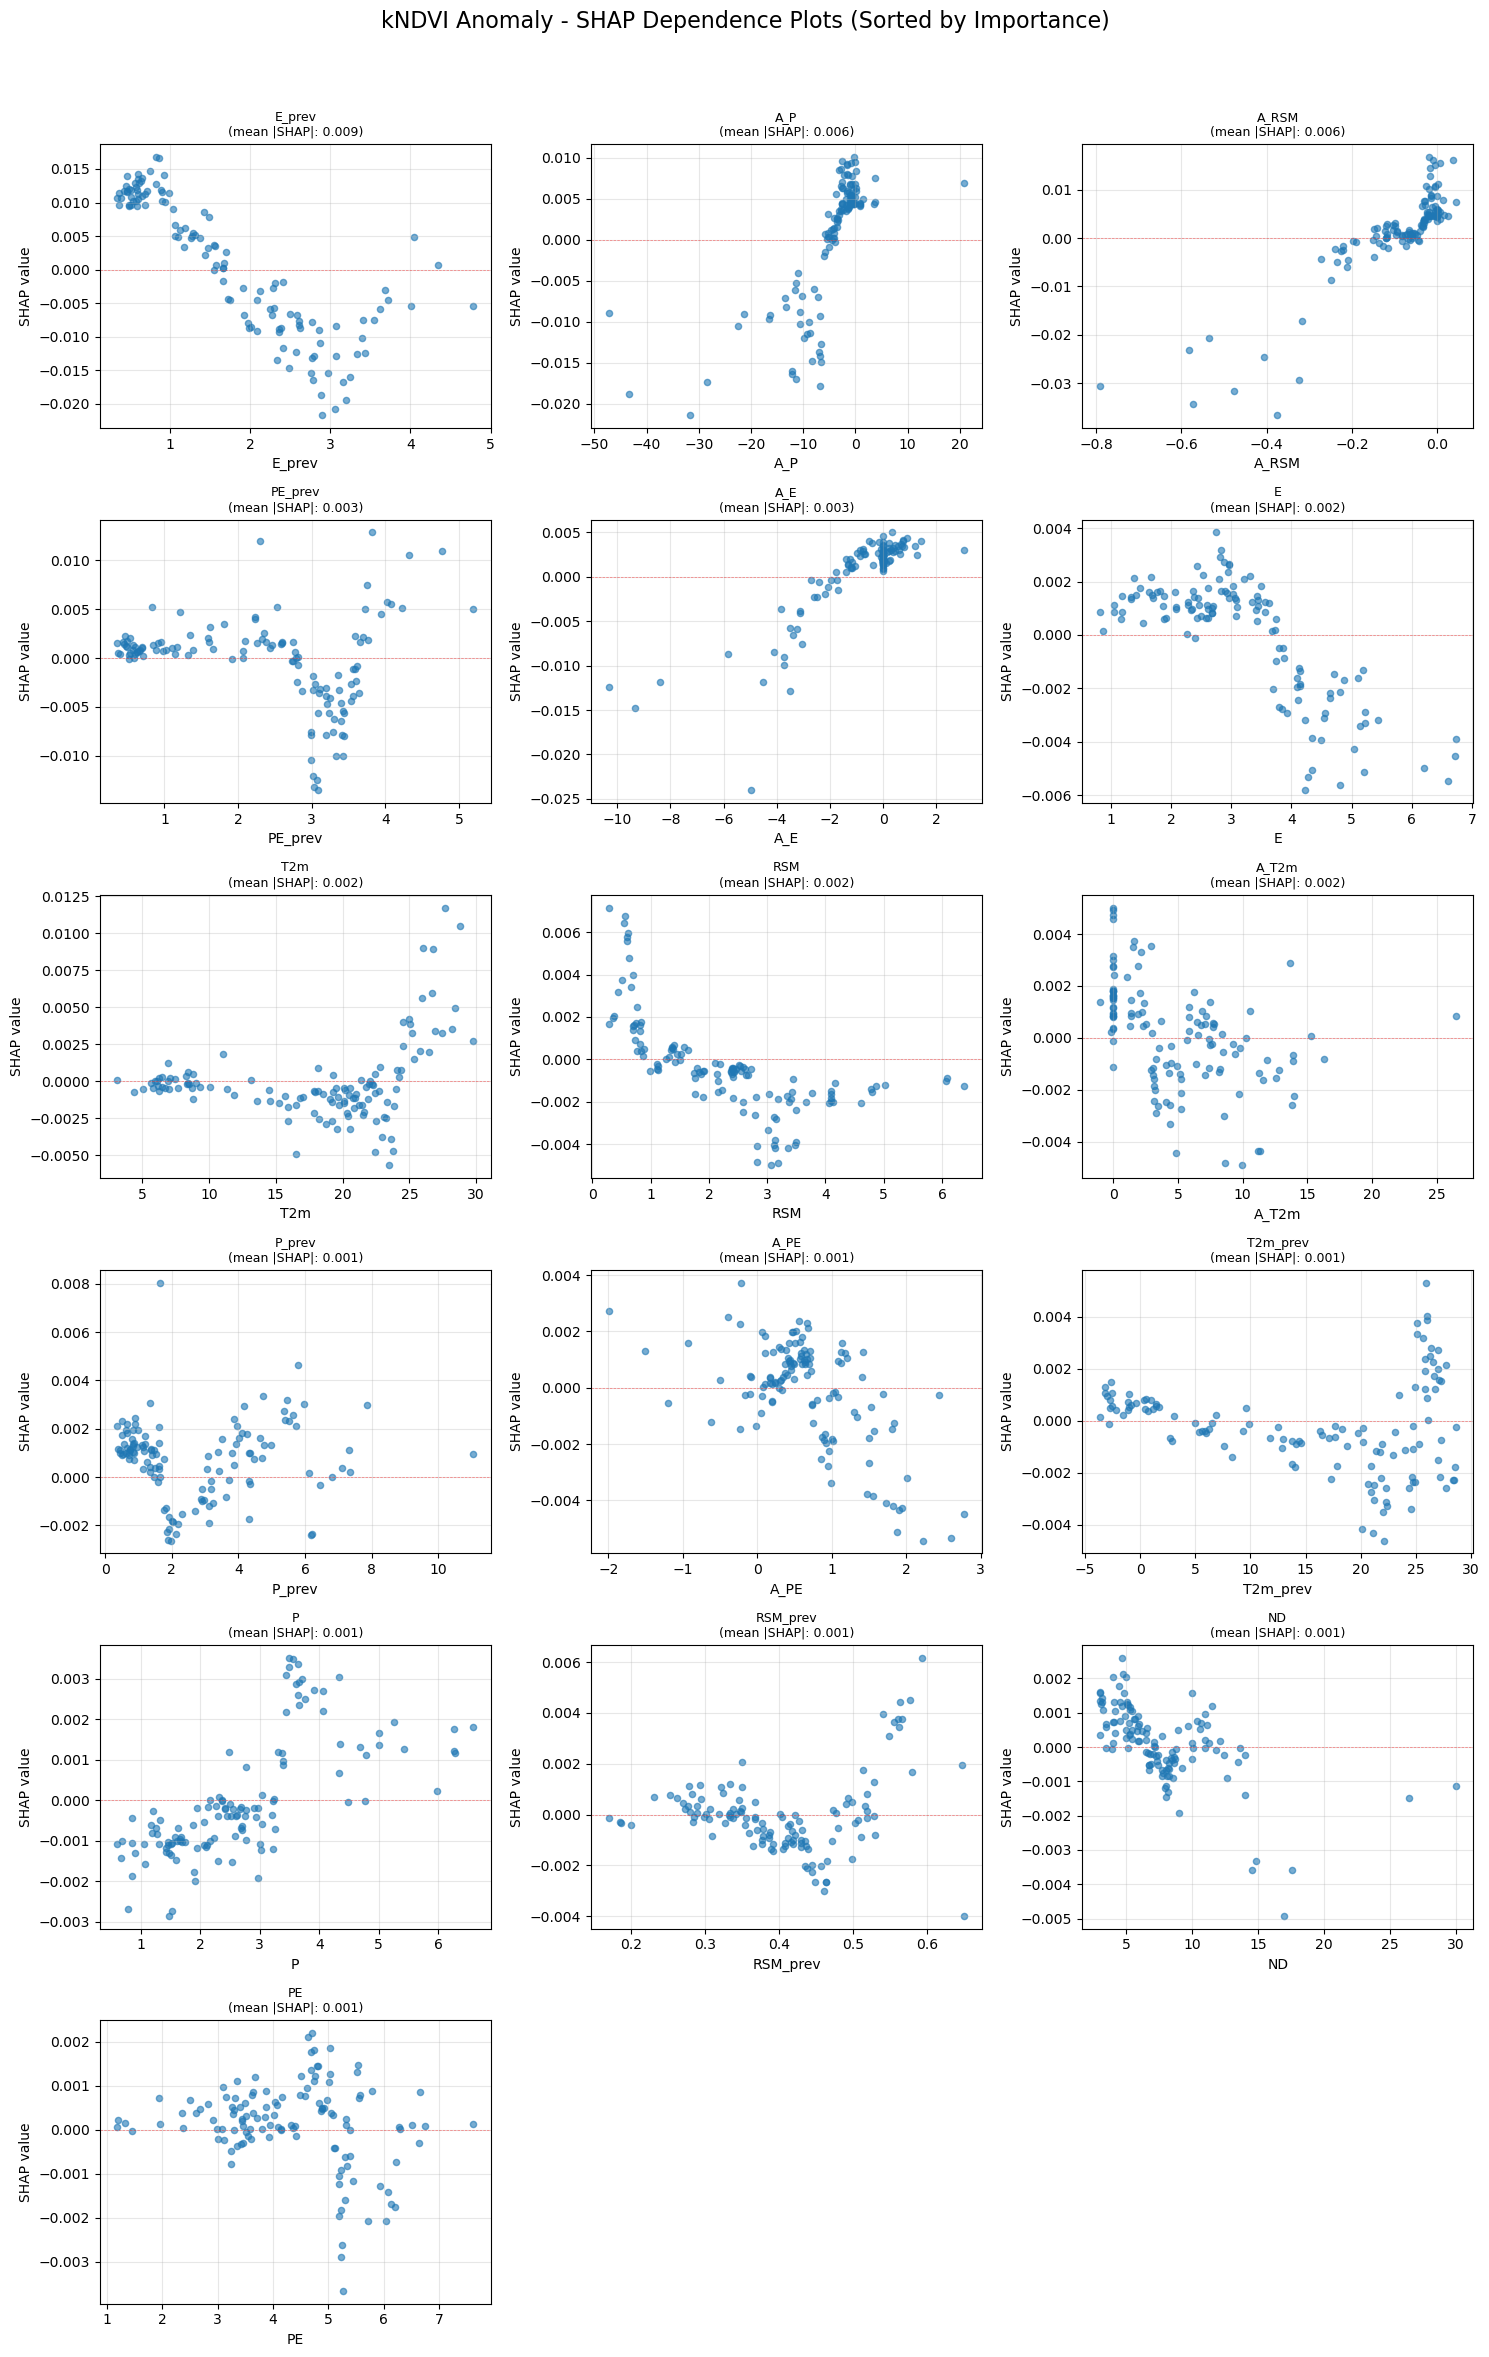

In [159]:

# Get feature names from X_test_rest
feature_names = X_test_anom.columns.tolist()

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = {}
for feature in feature_names:
    # Get feature index
    idx = feature_names.index(feature)
    # Calculate mean absolute SHAP value
    mean_abs = np.abs(shap_values_anom[:, idx].values).mean()
    mean_abs_shap[feature] = mean_abs

# Sort features by mean absolute SHAP value (descending)
sorted_features = sorted(mean_abs_shap.items(), key=lambda x: x[1], reverse=True)
feature_names_sorted = [f[0] for f in sorted_features]
shap_importance = [f[1] for f in sorted_features]

print("Features sorted by importance:")
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")

# Determine grid size for subplots
n_features = len(feature_names_sorted)
n_cols = 3  # Number of columns in the grid
n_rows = ceil(n_features / n_cols)

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
fig.suptitle("kNDVI Anomaly - SHAP Dependence Plots (Sorted by Importance)", fontsize=16)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create dependence plot for each feature
for i, feature in enumerate(feature_names_sorted):
    # Get feature index
    idx = feature_names.index(feature)
    
    # Extract SHAP values and feature values
    shap_values_feature = shap_values_anom[:, idx].values
    feature_values = X_test_anom[feature].values
    
    # Create scatter plot
    axes[i].scatter(feature_values, shap_values_feature, alpha=0.6, s=20)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("SHAP value", fontsize=10)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add importance score as title
    importance = mean_abs_shap[feature]
    axes[i].set_title(f"{feature}\n(mean |SHAP|: {importance:.3f})", fontsize=9)
    
    # Add grid for better readability
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# Export figure
output_path = '../document/Images/relat_anom_all.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()